<a href="https://colab.research.google.com/github/shellyycao/IDS705_ML_Final_Project_Group10/blob/main/IDS705_Group10_Notebook3_Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IDS 705 — Group 10: Vulnerability of Medical AI
## Notebook 3: Model Comparison Under Corruption Attacks
**PneumoniaMNIST+ (224×224) · ResNet-18 vs ResNet-50 vs DASYNet (3 weight variants)**

| Part | Description |
|------|-------------|
| 1 | Visual preview — 6 selected attacks × levels 0–5, two report figures |
| 2 | Bootstrap full-image attack evaluation (levels 1–5) for all 5 models |
| 3 | Degradation curves with ±2 SD error bars per model |
| 4 | Level-3 metric summary table (mean ± 2 SD) |
| 5 | Bootstrap mean distribution plots per model |

**Models evaluated:**
- ResNet-18 (pretrained MedMNIST weights)
- ResNet-50 (pretrained MedMNIST weights)
- DASYNet — `dasynet_pneumonia.pth` (baseline)
- DASYNet — `dasynet_finetuned.pth` (corruption-aware fine-tuned)
- DASYNet — `dasynet_finetuned_grid.pth` (grid fine-tuned)

**Selected attacks for comparison:**
Gaussian Blur (reference), FGSM (L1 ε=0.01), Gamma Underexposed, Contrast Low, Gamma Overexposed, Brightness Bright

**Bootstrap strategy:** 75 bootstrap resamples of the test set, reporting mean ± 2 SD.

## 0. Install & Import

In [1]:
!pip install medmnist scikit-learn seaborn --quiet

import os, io, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns
from PIL import Image, ImageFilter
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.models as tv_models

from medmnist import PneumoniaMNIST, INFO, Evaluator

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Constants

In [2]:
DATA_FLAG  = 'pneumoniamnist'
SIZE       = 224
BATCH_SIZE = 128
DATA_ROOT  = os.path.expanduser('~/.medmnist')

# Shared normalization (RGB models)
MEAN_RGB = [0.5, 0.5, 0.5]
STD_RGB  = [0.5, 0.5, 0.5]

# DASYNet uses grayscale
MEAN_GRAY = [0.5]
STD_GRAY  = [0.5]

info      = INFO[DATA_FLAG]
n_classes = len(info['label'])  # 2

# Bootstrap settings
N_BOOTSTRAP = 75
RANDOM_SEED = 42

# Robustness thresholds
ROBUST_THRESHOLD     = 0.02
CONCERNING_THRESHOLD = 0.05

# 6 selected attacks for comparison
SELECTED_ATTACKS = [
    'JPEC',
    'FGSM',
    'Gamma Underexposed',
    'Contrast Low',
    'Gamma Overexposed',
    'Brightness Bright',
]

# Weight paths on Google Drive
DRIVE_DIR = '/content/drive/MyDrive/ML_final'

DASYNET_WEIGHTS = {
    'DASYNet (pneumonia)' : os.path.join(DRIVE_DIR, 'dasynet_pneumonia.pth'),
    'DASYNet (finetuned)' : os.path.join(DRIVE_DIR, 'dasynet_finetuned.pth'),
    'DASYNet (grid)'      : os.path.join(DRIVE_DIR, 'dasynet_finetuned_grid.pth'),
}

# ResNet weight directories
WEIGHTS_DIR = './weights'
os.makedirs(WEIGHTS_DIR, exist_ok=True)

print(f'Task    : {info["task"]}')
print(f'Classes : {n_classes} -> {info["label"]}')
print(f'Bootstrap resamples: {N_BOOTSTRAP}')
print(f'Selected attacks: {SELECTED_ATTACKS}')

Task    : binary-class
Classes : 2 -> {'0': 'normal', '1': 'pneumonia'}
Bootstrap resamples: 75
Selected attacks: ['JPEC', 'FGSM', 'Gamma Underexposed', 'Contrast Low', 'Gamma Overexposed', 'Brightness Bright']


## 2. Download Dataset & Weights

In [3]:
import urllib.request

os.makedirs(DATA_ROOT, exist_ok=True)
NPZ_FILE = os.path.join(DATA_ROOT, 'pneumoniamnist_224.npz')

if not os.path.exists(NPZ_FILE):
    print('Downloading PneumoniaMNIST+ 224...')
    url = 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1'
    urllib.request.urlretrieve(url, NPZ_FILE)
    print('Done.')
else:
    print(f'Dataset present: {NPZ_FILE}')

# Download ResNet-18 weights
import requests, zipfile

RESNET18_FILE = os.path.join(WEIGHTS_DIR, 'resnet18_224_1.pth')
RESNET50_FILE = os.path.join(WEIGHTS_DIR, 'resnet50_224_1.pth')

if not os.path.exists(RESNET18_FILE) or not os.path.exists(RESNET50_FILE):
    print('Downloading MedMNIST pretrained weights...')
    ZIP_URL  = 'https://zenodo.org/records/7782114/files/weights_pneumoniamnist.zip?download=1'
    ZIP_PATH = '/tmp/weights_pneumoniamnist.zip'
    r = requests.get(ZIP_URL, stream=True)
    with open(ZIP_PATH, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(WEIGHTS_DIR)
    print('Weights extracted.')
    import glob
    print('Available weight files:', glob.glob(os.path.join(WEIGHTS_DIR, '**/*.pth'), recursive=True))
else:
    print('ResNet weights already present.')

Dataset present: /root/.medmnist/pneumoniamnist_224.npz
ResNet weights already present.


## 3. Mount Google Drive (for DASYNet weights)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

for name, path in DASYNET_WEIGHTS.items():
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{status}] {name}: {path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  [OK] DASYNet (pneumonia): /content/drive/MyDrive/ML_final/dasynet_pneumonia.pth
  [OK] DASYNet (finetuned): /content/drive/MyDrive/ML_final/dasynet_finetuned.pth
  [OK] DASYNet (grid): /content/drive/MyDrive/ML_final/dasynet_finetuned_grid.pth


## 4. Model Definitions & Loaders

In [5]:
# ── DASYNet architecture ───────────────────────────────────────────────────────
class DASYNET(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super(DASYNET, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d((3, 3))
        self.flatten     = nn.Flatten()
        self.classifier  = nn.Sequential(
            nn.Linear(64 * 3 * 3, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x)
        x = self.flatten(x)
        return self.classifier(x)


def load_resnet18():
    model = tv_models.resnet18(weights=None, num_classes=n_classes)
    ckpt  = torch.load(RESNET18_FILE, map_location=device)
    state = ckpt['net'] if (isinstance(ckpt, dict) and 'net' in ckpt) else ckpt
    model.load_state_dict(state, strict=True)
    model.to(device).eval()
    print(f'ResNet-18 loaded — {sum(p.numel() for p in model.parameters()):,} params')
    return model


def load_resnet50():
    model = tv_models.resnet50(weights=None, num_classes=n_classes)
    ckpt  = torch.load(RESNET50_FILE, map_location=device)
    state = ckpt['net'] if (isinstance(ckpt, dict) and 'net' in ckpt) else ckpt
    model.load_state_dict(state, strict=True)
    model.to(device).eval()
    print(f'ResNet-50 loaded — {sum(p.numel() for p in model.parameters()):,} params')
    return model


def load_dasynet(weight_path):
    model = DASYNET(in_channels=1, num_classes=n_classes)
    ckpt  = torch.load(weight_path, map_location=device)
    # Handle both bare state dict and wrapped checkpoint
    state = ckpt['net'] if (isinstance(ckpt, dict) and 'net' in ckpt) else ckpt
    model.load_state_dict(state)
    model.to(device).eval()
    print(f'DASYNet loaded from {os.path.basename(weight_path)} — {sum(p.numel() for p in model.parameters()):,} params')
    return model


print('Model loader functions defined.')

Model loader functions defined.


In [6]:
# Load all models
resnet18 = load_resnet18()
resnet50 = load_resnet50()

dasynet_models = {}
for name, path in DASYNET_WEIGHTS.items():
    dasynet_models[name] = load_dasynet(path)

# All models registry — (model_object, is_grayscale)
ALL_MODELS = {
    'ResNet-18'           : (resnet18,                      False),
    'ResNet-50'           : (resnet50,                      False),
    'DASYNet (pneumonia)' : (dasynet_models['DASYNet (pneumonia)'], True),
    'DASYNet (finetuned)' : (dasynet_models['DASYNet (finetuned)'], True),
    'DASYNet (grid)'      : (dasynet_models['DASYNet (grid)'],      True),
}

print(f'\nAll models loaded: {list(ALL_MODELS.keys())}')

ResNet-18 loaded — 11,177,538 params
ResNet-50 loaded — 23,512,130 params
DASYNet loaded from dasynet_pneumonia.pth — 97,634 params
DASYNet loaded from dasynet_finetuned.pth — 97,634 params
DASYNet loaded from dasynet_finetuned_grid.pth — 97,634 params

All models loaded: ['ResNet-18', 'ResNet-50', 'DASYNet (pneumonia)', 'DASYNet (finetuned)', 'DASYNet (grid)']


## 5. Attack Definitions

In [7]:
ATTACK_LEVELS = {
    'Gaussian Blur'      : [(3, 0.5), (7, 1.0), (11, 2.0), (15, 3.0), (21, 5.0)],
    'Downsampling'       : [0.5, 0.4, 0.3, 0.2, 0.1],
    'JPEG'               : [75, 50, 30, 15, 5],
    'Brightness Dark'    : [-0.1, -0.2, -0.3, -0.4, -0.5],
    'Brightness Bright'  : [0.1,  0.2,  0.3,  0.4,  0.5],
    'Contrast Low'       : [0.8,  0.6,  0.4,  0.3,  0.2],
    'Contrast High'      : [1.2,  1.4,  1.6,  1.8,  2.0],
    'Gamma Overexposed'  : [0.9,  0.7,  0.5,  0.3,  0.1],
    'Gamma Underexposed' : [1.5,  2.0,  3.0,  4.0,  5.0],
    'FGSM'               : [0.001, 0.005, 0.01, 0.015, 0.02],
}
ATTACK_NAMES = list(ATTACK_LEVELS.keys())


def jpeg_compress_pil(img, quality):
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).copy()


def apply_gamma(t, gamma):
    t_01    = (t + 1) / 2
    t_gamma = torch.pow(t_01.clamp(min=1e-8), gamma)
    return (t_gamma * 2 - 1).clamp(-1, 1)


print(f'Attack types: {len(ATTACK_NAMES)}')
print(f'Selected for comparison: {SELECTED_ATTACKS}')

Attack types: 10
Selected for comparison: ['JPEC', 'FGSM', 'Gamma Underexposed', 'Contrast Low', 'Gamma Overexposed', 'Brightness Bright']


## 6. Transform Builder (RGB and Grayscale)

In [8]:
def make_clean_transform(grayscale=False):
    channel_fn = (lambda img: img.convert('L')) if grayscale else (lambda img: img.convert('RGB'))
    mean = MEAN_GRAY if grayscale else MEAN_RGB
    std  = STD_GRAY  if grayscale else STD_RGB
    return transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(channel_fn),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])


def make_attack_transform(attack_name, level_idx, grayscale=False):
    """Build a PIL + tensor transform for a given attack. FGSM returns None."""
    if attack_name == 'FGSM':
        return None

    channel_fn = (lambda img: img.convert('L')) if grayscale else (lambda img: img.convert('RGB'))
    mean = MEAN_GRAY if grayscale else MEAN_RGB
    std  = STD_GRAY  if grayscale else STD_RGB

    param = ATTACK_LEVELS[attack_name][level_idx]
    pil_steps    = [
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(channel_fn),
    ]
    tensor_steps = []

    if attack_name == 'Gaussian Blur':
        ks, sig = param
        pil_steps.append(transforms.GaussianBlur(kernel_size=ks, sigma=sig))
    elif attack_name == 'Downsampling':
        small = max(1, int(SIZE * param))
        pil_steps.append(transforms.Resize((small, small), interpolation=Image.NEAREST))
        pil_steps.append(transforms.Resize((SIZE, SIZE),   interpolation=Image.NEAREST))
    elif attack_name == 'JPEG':
        pil_steps.append(transforms.Lambda(lambda img, q=param: jpeg_compress_pil(img, q)))
    elif attack_name in ('Brightness Dark', 'Brightness Bright'):
        tensor_steps.append(transforms.Lambda(lambda t, d=param: torch.clamp(t + d, -1.0, 1.0)))
    elif attack_name in ('Contrast Low', 'Contrast High'):
        tensor_steps.append(transforms.Lambda(lambda t, a=param: torch.clamp(t * a, -1.0, 1.0)))
    elif attack_name in ('Gamma Overexposed', 'Gamma Underexposed'):
        tensor_steps.append(transforms.Lambda(lambda t, g=param: apply_gamma(t, g)))

    return transforms.Compose(
        pil_steps +
        [transforms.ToTensor(), transforms.Normalize(mean=mean, std=std)] +
        tensor_steps
    )


def make_loader(transform, indices=None):
    ds = PneumoniaMNIST(split='test', transform=transform,
                        download=False, root=DATA_ROOT, size=SIZE)
    if indices is not None:
        ds = Subset(ds, indices)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


print('Transform builder ready (RGB + grayscale) ✓')

Transform builder ready (RGB + grayscale) ✓


## 7. Inference & Evaluation Functions

In [38]:
def run_inference(model, loader):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            scores = torch.softmax(logits, dim=1)
            all_scores.append(scores.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


def run_fgsm_inference(model, epsilon, grayscale=False, indices=None):
    clean_tfm = make_clean_transform(grayscale=grayscale)
    ds = PneumoniaMNIST(split='test', transform=clean_tfm,
                        download=False, root=DATA_ROOT, size=SIZE)
    if indices is not None:
        ds = Subset(ds, indices)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    criterion = nn.CrossEntropyLoss()
    model.train()   # <-- CHANGE: must be train() for gradients to flow through BatchNorm etc.
    all_scores, all_labels = [], []

    for images, labels in loader:
        images   = images.to(device).requires_grad_(True)
        labels_t = labels.squeeze().long().to(device)

        logits = model(images)
        loss   = criterion(logits, labels_t)
        model.zero_grad()
        loss.backward()

        perturbed = (images + epsilon * images.grad.sign()).clamp(-1.0, 1.0).detach()

        with torch.no_grad():
            model.eval()   # switch to eval for the clean scoring pass
            scores = torch.softmax(model(perturbed), dim=1)
            model.train()  # switch back for next batch

        all_scores.append(scores.cpu().numpy())
        all_labels.append(labels.numpy())

    model.eval()   # restore eval mode when done
    return np.concatenate(all_scores), np.concatenate(all_labels)


def compute_metrics_simple(y_score, y_true):
    """Compute metrics without medmnist.Evaluator (for bootstrap subsets)."""
    y_pred   = (y_score[:, 1] >= 0.5).astype(int)
    y_true_f = y_true.flatten().astype(int)
    acc      = float(np.mean(y_pred == y_true_f))
    try:
        auroc = roc_auc_score(y_true_f, y_score[:, 1])
    except Exception:
        auroc = float('nan')
    return {
        'accuracy' : acc,
        'auroc'    : float(auroc),
        'precision': precision_score(y_true_f, y_pred, zero_division=0),
        'recall'   : recall_score(y_true_f, y_pred, zero_division=0),
        'f1'       : f1_score(y_true_f, y_pred, zero_division=0),
    }


print('Inference & evaluation functions ready ✓')

Inference & evaluation functions ready ✓


## 8. Bootstrap Evaluation Engine

In [39]:
def get_test_size():
    """Get total number of test samples."""
    ds = PneumoniaMNIST(split='test', transform=None, download=False, root=DATA_ROOT, size=SIZE)
    return len(ds)


def bootstrap_attack(model, attack_name, level_idx, grayscale,
                     n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED):
    """
    Run n_bootstrap resamples of the test set for a given attack and level.
    Returns dict: {metric_name: array of length n_bootstrap}.
    """
    rng      = np.random.RandomState(seed)
    n_test   = get_test_size()
    metric_keys = ['accuracy', 'auroc', 'precision', 'recall', 'f1']
    bootstrap_vals = {k: [] for k in metric_keys}

    # First run full inference on the complete attacked test set
    if attack_name == 'FGSM':
        epsilon = ATTACK_LEVELS['FGSM'][level_idx]
        y_score_full, y_true_full = run_fgsm_inference(model, epsilon, grayscale=grayscale)
    else:
        tfm = make_attack_transform(attack_name, level_idx, grayscale=grayscale)
        loader = make_loader(tfm)
        y_score_full, y_true_full = run_inference(model, loader)

    y_true_full = y_true_full.flatten()

    # Bootstrap resample from cached full predictions
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n_test, size=n_test)
        m   = compute_metrics_simple(y_score_full[idx], y_true_full[idx])
        for k in metric_keys:
            bootstrap_vals[k].append(m[k])

    return {k: np.array(v) for k, v in bootstrap_vals.items()}


def summarize_bootstrap(bs_vals):
    """Return mean and 2*std for each metric."""
    return {
        k: {'mean': float(np.mean(v)), 'sd2': float(2 * np.std(v))}
        for k, v in bs_vals.items()
    }


print('Bootstrap engine ready ✓')
print(f'Each evaluation = {N_BOOTSTRAP} bootstrap resamples over the full test set.')

Bootstrap engine ready ✓
Each evaluation = 75 bootstrap resamples over the full test set.


---
# PART 1 — Visual Preview of Attacks

Two report-ready figures:
- **Figure A**: 6 selected attacks at Level 3 (2×3 grid)
- **Figure B**: Gamma Underexposed at Levels 0–5 in 2×3 layout, plus one other attack

Both shown on a real pneumonia chest X-ray.

In [11]:
# Load a sample pneumonia image for display
raw_ds = PneumoniaMNIST(split='test', transform=None,
                        download=False, root=DATA_ROOT, size=SIZE)

sample_img = None
for i in range(len(raw_ds)):
    img_pil, lbl = raw_ds[i]
    if int(np.array(lbl).item()) == 1:  # pneumonia class
        sample_img = img_pil.resize((SIZE, SIZE), Image.NEAREST).convert('RGB')
        break

print(f'Sample image loaded — size: {sample_img.size}, mode: {sample_img.mode}')


def pil_preview_rgb(attack_name, level_idx):
    """Apply PIL-space corruption and return a displayable RGB PIL image."""
    img = sample_img.copy()

    if attack_name == 'Gaussian Blur':
        ks, sig = ATTACK_LEVELS[attack_name][level_idx]
        img = img.filter(ImageFilter.GaussianBlur(radius=sig))

    elif attack_name == 'Downsampling':
        scale = ATTACK_LEVELS[attack_name][level_idx]
        small = max(1, int(SIZE * scale))
        img   = img.resize((small, small), Image.NEAREST).resize((SIZE, SIZE), Image.NEAREST)

    elif attack_name == 'JPEG':
        quality = ATTACK_LEVELS[attack_name][level_idx]
        img     = jpeg_compress_pil(img, quality)

    else:
        # Tensor-space: apply via numpy
        arr  = np.array(img).astype(np.float32) / 127.5 - 1.0  # [-1,1]
        param = ATTACK_LEVELS[attack_name][level_idx]

        if attack_name in ('Brightness Dark', 'Brightness Bright'):
            arr = np.clip(arr + param, -1.0, 1.0)
        elif attack_name in ('Contrast Low', 'Contrast High'):
            arr = np.clip(arr * param, -1.0, 1.0)
        elif attack_name in ('Gamma Overexposed', 'Gamma Underexposed'):
            arr_01  = (arr + 1) / 2
            arr_01  = np.power(np.clip(arr_01, 1e-8, None), param)
            arr     = np.clip(arr_01 * 2 - 1, -1.0, 1.0)
        elif attack_name == 'FGSM':
            # For display: add small random noise to represent FGSM effect
            eps = ATTACK_LEVELS['FGSM'][level_idx]
            arr = np.clip(arr + eps * np.sign(np.random.randn(*arr.shape)), -1.0, 1.0)

        arr_uint8 = ((arr + 1) / 2 * 255).astype(np.uint8)
        img = Image.fromarray(arr_uint8)

    return img


print('Preview function ready ✓')

Sample image loaded — size: (224, 224), mode: RGB
Preview function ready ✓


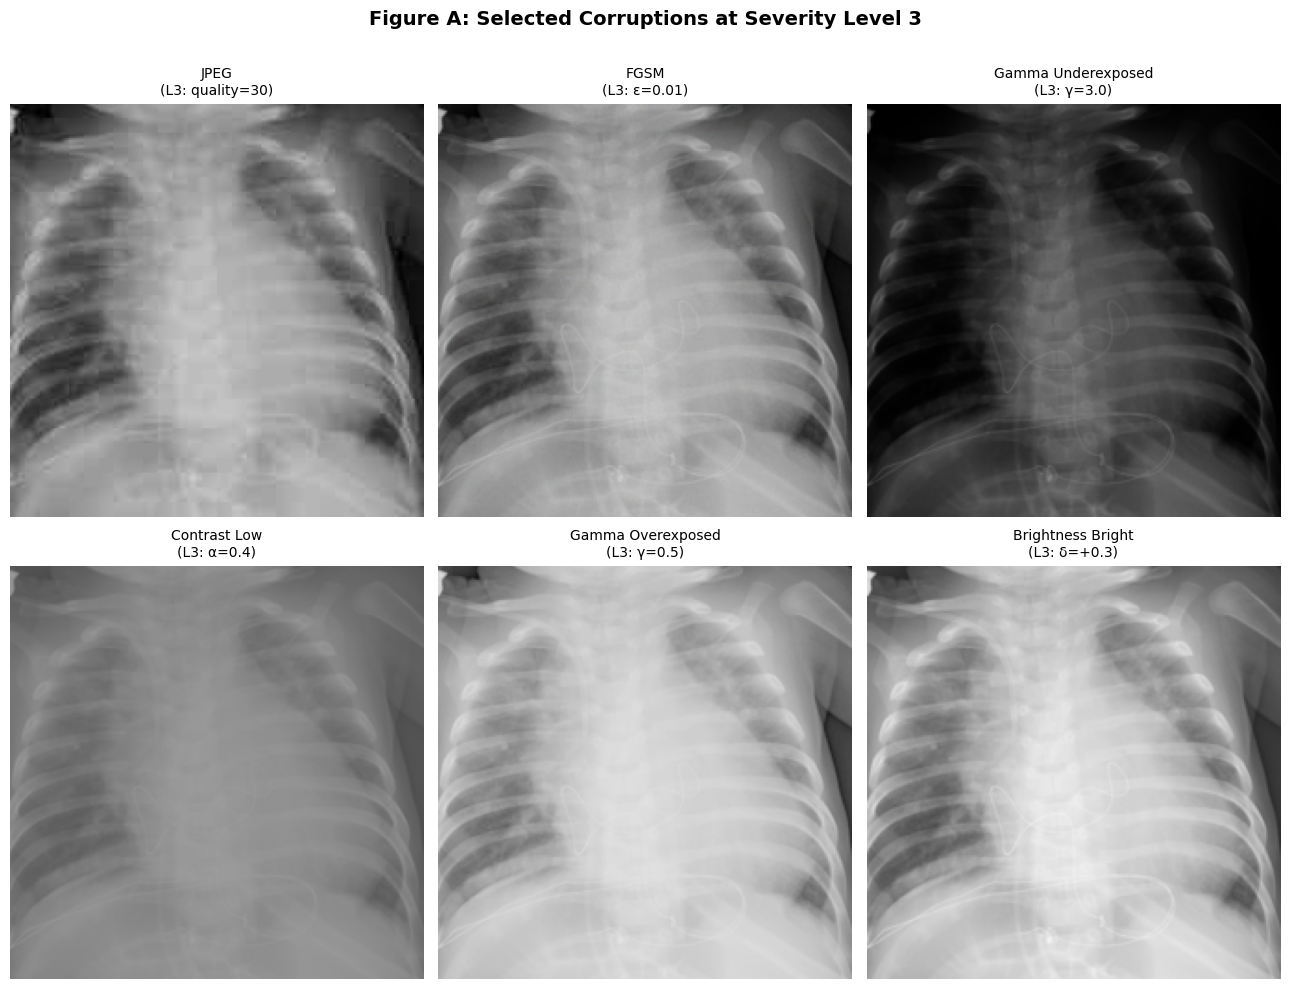

Figure A saved: figure_A_attacks_level3.png


In [32]:
# ── FIGURE A: 6 selected attacks at Level 3 (2×3 grid) ───────────────────────
# This is a report figure — clean, labeled, no borders

LEVEL_3_IDX = 2  # Level 3 = index 2 (0-based)

SELECTED_ATTACKS = [
    'JPEG',
    'FGSM',
    'Gamma Underexposed',
    'Contrast Low',
    'Gamma Overexposed',
    'Brightness Bright',
]

fig, axes = plt.subplots(2, 3, figsize=(13, 10))
fig.suptitle('Figure A: Selected Corruptions at Severity Level 3',
             fontsize=14, fontweight='bold', y=1.01)

for ax, atk in zip(axes.flatten(), SELECTED_ATTACKS):
    img_preview = pil_preview_rgb(atk, LEVEL_3_IDX)
    ax.imshow(img_preview, cmap='gray' if img_preview.mode == 'L' else None)
    ax.set_title(attack_display_names[atk], fontsize=10, pad=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('figure_A_attacks_level3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure A saved: figure_A_attacks_level3.png')

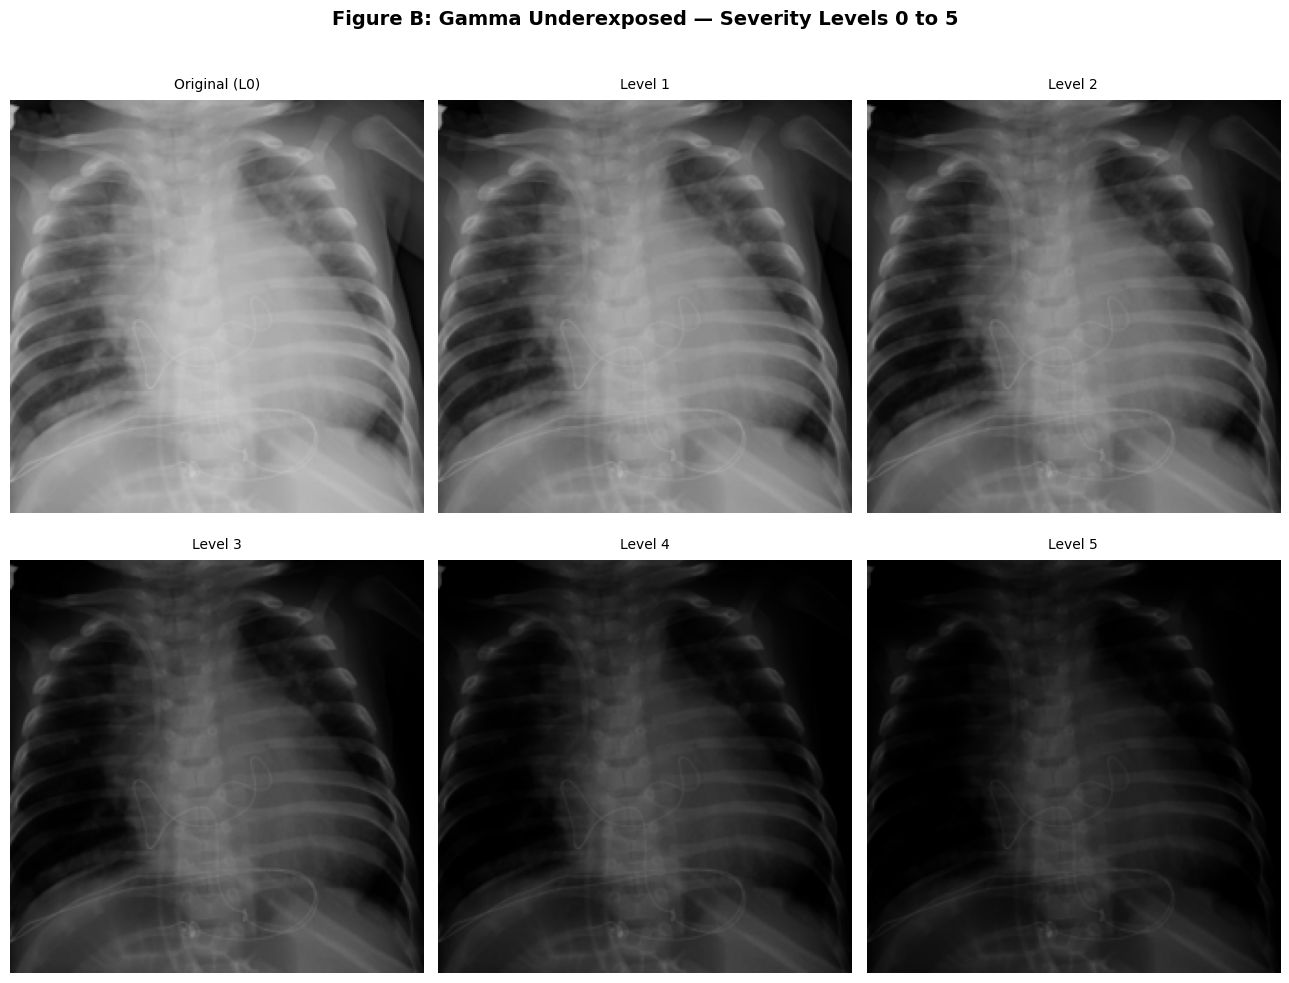

Figure B saved: figure_B_gamma_underexposed_levels.png


In [33]:
# ── FIGURE B: Corruption levels 0–5 for the 6 selected attacks (2×3 grid each) ─
# One figure per attack showing all severity levels for the report
# Arranged as: original (L0) + L1...L5 in a 2x3 grid

LEVEL_LABELS = ['Original (L0)', 'Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']

fig, axes = plt.subplots(2, 3, figsize=(13, 10))
fig.suptitle('Figure B: Gamma Underexposed — Severity Levels 0 to 5',
             fontsize=14, fontweight='bold', y=1.01)

for col_idx, (ax, label) in enumerate(zip(axes.flatten(), LEVEL_LABELS)):
    if col_idx == 0:
        img_preview = sample_img.copy()
    else:
        img_preview = pil_preview_rgb('Gamma Underexposed', col_idx - 1)
    ax.imshow(img_preview, cmap='gray' if img_preview.mode == 'L' else None)
    ax.set_title(label, fontsize=10, pad=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('figure_B_gamma_underexposed_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure B saved: figure_B_gamma_underexposed_levels.png')

In [ ]:
# ── FIGURE B2: Gamma Overexposed levels 0–5 (2×3 grid) ───────────────────────

fig, axes = plt.subplots(2, 3, figsize=(12, 8.5))
fig.suptitle('Figure B2: Gamma Overexposed — Severity Levels 0 to 5',
             fontsize=14, fontweight='bold', y=1.01)

for col_idx, (ax, label) in enumerate(zip(axes.flatten(), LEVEL_LABELS)):
    if col_idx == 0:
        img_preview = sample_img.copy()
    else:
        img_preview = pil_preview_rgb('Gamma Overexposed', col_idx - 1)
    ax.imshow(img_preview, cmap='gray' if img_preview.mode == 'L' else None)
    ax.set_title(label, fontsize=10, pad=6)
    ax.axis('off')

plt.tight_layout()
plt.savefig('figure_B2_gamma_overexposed_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure B2 saved: figure_B2_gamma_overexposed_levels.png')

---
# PART 2 — Bootstrap Full-Image Attack Evaluation

For each of the 5 models × 6 attacks × 5 levels, run 75 bootstrap resamples.
This cell is compute-heavy. Expected runtime on T4 GPU: ~45–90 minutes total.

Results are stored in `all_results[model_name][attack_name][level]` as bootstrap arrays.

In [15]:
# Run bootstrap evaluation for all models, attacks, and levels
# Structure: all_results[model_name][attack_name][level_idx] = {metric: array}

all_results = {}

total_jobs = len(ALL_MODELS) * len(SELECTED_ATTACKS) * 5
done = 0

for model_name, (model, grayscale) in ALL_MODELS.items():
    print(f'\n{"="*60}')
    print(f'Model: {model_name}')
    print(f'{"="*60}')
    all_results[model_name] = {}

    for attack_name in SELECTED_ATTACKS:
        print(f'  Attack: {attack_name}')
        all_results[model_name][attack_name] = {}

        for level_idx in range(5):  # Levels 1–5 (index 0–4)
            level_num = level_idx + 1
            bs_vals = bootstrap_attack(
                model, attack_name, level_idx, grayscale,
                n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED + level_idx
            )
            all_results[model_name][attack_name][level_num] = bs_vals
            summary = summarize_bootstrap(bs_vals)
            acc_m   = summary['accuracy']['mean']
            acc_sd2 = summary['accuracy']['sd2']
            done += 1
            print(f'    L{level_num}: Acc = {acc_m:.4f} ± {acc_sd2:.4f}  [{done}/{total_jobs}]')

print('\n✓ All bootstrap evaluations complete.')


Model: ResNet-18
  Attack: JPEG
    L1: Acc = 0.8918 ± 0.0213  [1/150]
    L2: Acc = 0.8973 ± 0.0216  [2/150]
    L3: Acc = 0.8933 ± 0.0243  [3/150]
    L4: Acc = 0.8853 ± 0.0229  [4/150]
    L5: Acc = 0.8915 ± 0.0248  [5/150]
  Attack: FGSM
    L1: Acc = 0.8724 ± 0.0243  [6/150]
    L2: Acc = 0.7985 ± 0.0271  [7/150]
    L3: Acc = 0.6415 ± 0.0358  [8/150]
    L4: Acc = 0.4676 ± 0.0414  [9/150]
    L5: Acc = 0.3086 ± 0.0353  [10/150]
  Attack: Gamma Underexposed
    L1: Acc = 0.8765 ± 0.0277  [11/150]
    L2: Acc = 0.8388 ± 0.0276  [12/150]
    L3: Acc = 0.6927 ± 0.0341  [13/150]
    L4: Acc = 0.6495 ± 0.0389  [14/150]
    L5: Acc = 0.6293 ± 0.0362  [15/150]
  Attack: Contrast Low
    L1: Acc = 0.8939 ± 0.0233  [16/150]
    L2: Acc = 0.8707 ± 0.0262  [17/150]
    L3: Acc = 0.7885 ± 0.0286  [18/150]
    L4: Acc = 0.6999 ± 0.0343  [19/150]
    L5: Acc = 0.6263 ± 0.0364  [20/150]
  Attack: Gamma Overexposed
    L1: Acc = 0.8848 ± 0.0241  [21/150]
    L2: Acc = 0.8484 ± 0.0256  [22/150]
 

## Compute Clean Baselines (with bootstrap)

In [16]:
baselines = {}  # {model_name: {metric: {'mean', 'sd2'}}}

rng    = np.random.RandomState(RANDOM_SEED)
n_test = get_test_size()

for model_name, (model, grayscale) in ALL_MODELS.items():
    tfm    = make_clean_transform(grayscale=grayscale)
    loader = make_loader(tfm)
    y_score_full, y_true_full = run_inference(model, loader)
    y_true_full = y_true_full.flatten()

    metric_keys = ['accuracy', 'auroc', 'precision', 'recall', 'f1']
    bs_clean    = {k: [] for k in metric_keys}

    for _ in range(N_BOOTSTRAP):
        idx = rng.randint(0, n_test, size=n_test)
        m   = compute_metrics_simple(y_score_full[idx], y_true_full[idx])
        for k in metric_keys:
            bs_clean[k].append(m[k])

    baselines[model_name] = summarize_bootstrap({k: np.array(v) for k, v in bs_clean.items()})
    acc_m   = baselines[model_name]['accuracy']['mean']
    acc_sd2 = baselines[model_name]['accuracy']['sd2']
    print(f'{model_name:30s}  Clean Acc = {acc_m:.4f} ± {acc_sd2:.4f}')

print('\nClean baselines computed.')

ResNet-18                       Clean Acc = 0.8918 ± 0.0213
ResNet-50                       Clean Acc = 0.8899 ± 0.0302
DASYNet (pneumonia)             Clean Acc = 0.9019 ± 0.0227
DASYNet (finetuned)             Clean Acc = 0.8968 ± 0.0235
DASYNet (grid)                  Clean Acc = 0.8820 ± 0.0219

Clean baselines computed.


---
# PART 3 — Degradation Curves with ±2 SD Error Bars

One subplot per selected attack. All 5 models plotted together.
X-axis: Clean + L1–L5. Y-axis: Accuracy (mean ± 2 SD).

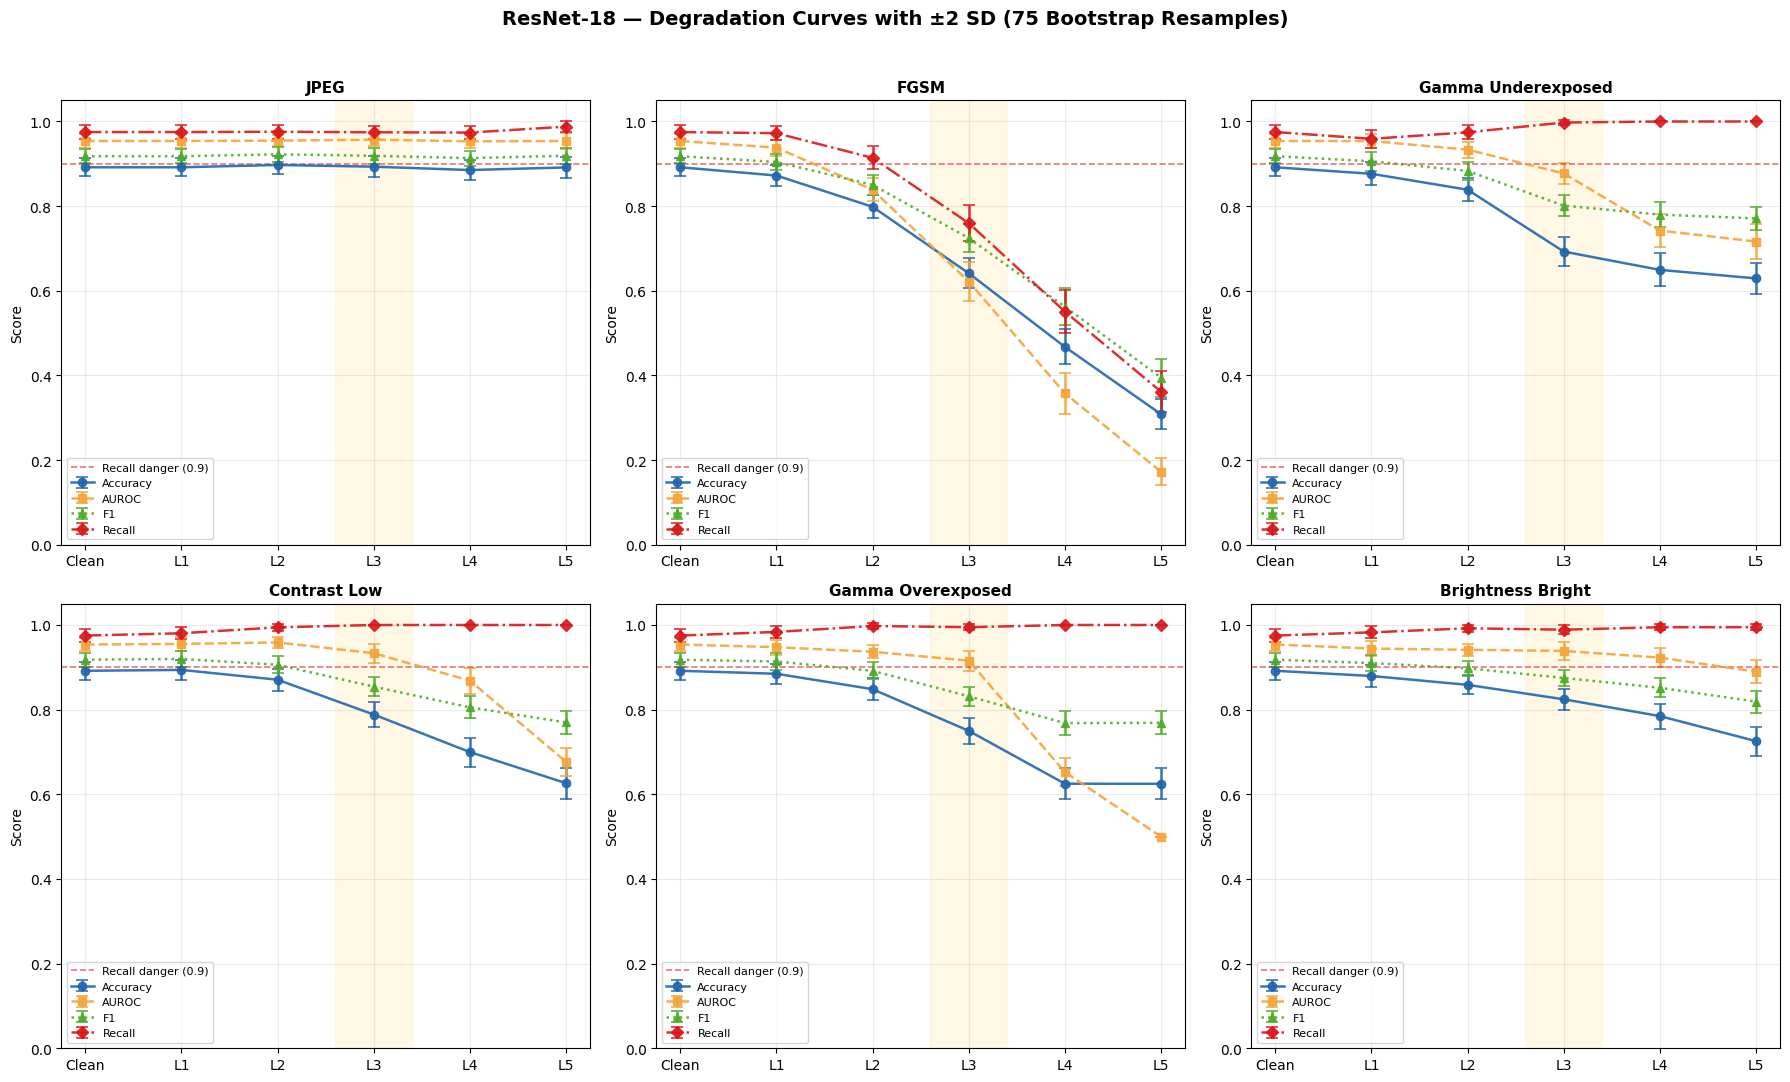

Saved: figure_resnet18_degradation_curves.png


In [34]:
# Degradation curves for ResNet-18 — 6 selected attacks with ±2SD error bars
# Metrics: Accuracy, AUROC, F1, Recall

model_name = 'ResNet-18'
model, grayscale = ALL_MODELS[model_name]

x_pos    = list(range(6))  # 0=Clean, 1–5=L1–L5
x_labels = ['Clean', 'L1', 'L2', 'L3', 'L4', 'L5']

METRIC_STYLES = {
    'accuracy' : ('o-',  '#2166ac', 'Accuracy'),
    'auroc'    : ('s--', '#f4a43a', 'AUROC'),
    'f1'       : ('^:',  '#4dac26', 'F1'),
    'recall'   : ('D-.', '#d7191c', 'Recall'),
}

RECALL_DANGER = 0.90

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
fig.suptitle('ResNet-18 — Degradation Curves with ±2 SD (75 Bootstrap Resamples)',
             fontsize=14, fontweight='bold')

for ax_idx, attack_name in enumerate(SELECTED_ATTACKS):
    ax = axes[ax_idx]

    for metric, (fmt, color, label) in METRIC_STYLES.items():
        # Clean baseline point
        means = [baselines[model_name][metric]['mean']]
        sd2s  = [baselines[model_name][metric]['sd2']]

        for level_num in range(1, 6):
            bs  = all_results[model_name][attack_name][level_num]
            means.append(np.mean(bs[metric]))
            sd2s.append(2 * np.std(bs[metric]))

        means = np.array(means)
        sd2s  = np.array(sd2s)

        ax.errorbar(x_pos, means, yerr=sd2s,
                    fmt=fmt, color=color, label=label,
                    capsize=4, capthick=1.2, linewidth=1.8,
                    markersize=6, alpha=0.9)

    # Recall danger threshold
    ax.axhline(y=RECALL_DANGER, color='#d7191c', linestyle='--',
               linewidth=1.2, alpha=0.6, label=f'Recall danger ({RECALL_DANGER})')

    # Shade L3 column
    ax.axvspan(2.6, 3.4, color='#fff3cd', alpha=0.5, zorder=0)

    ax.set_title(attack_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel('Score')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc='lower left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('figure_resnet18_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figure_resnet18_degradation_curves.png')

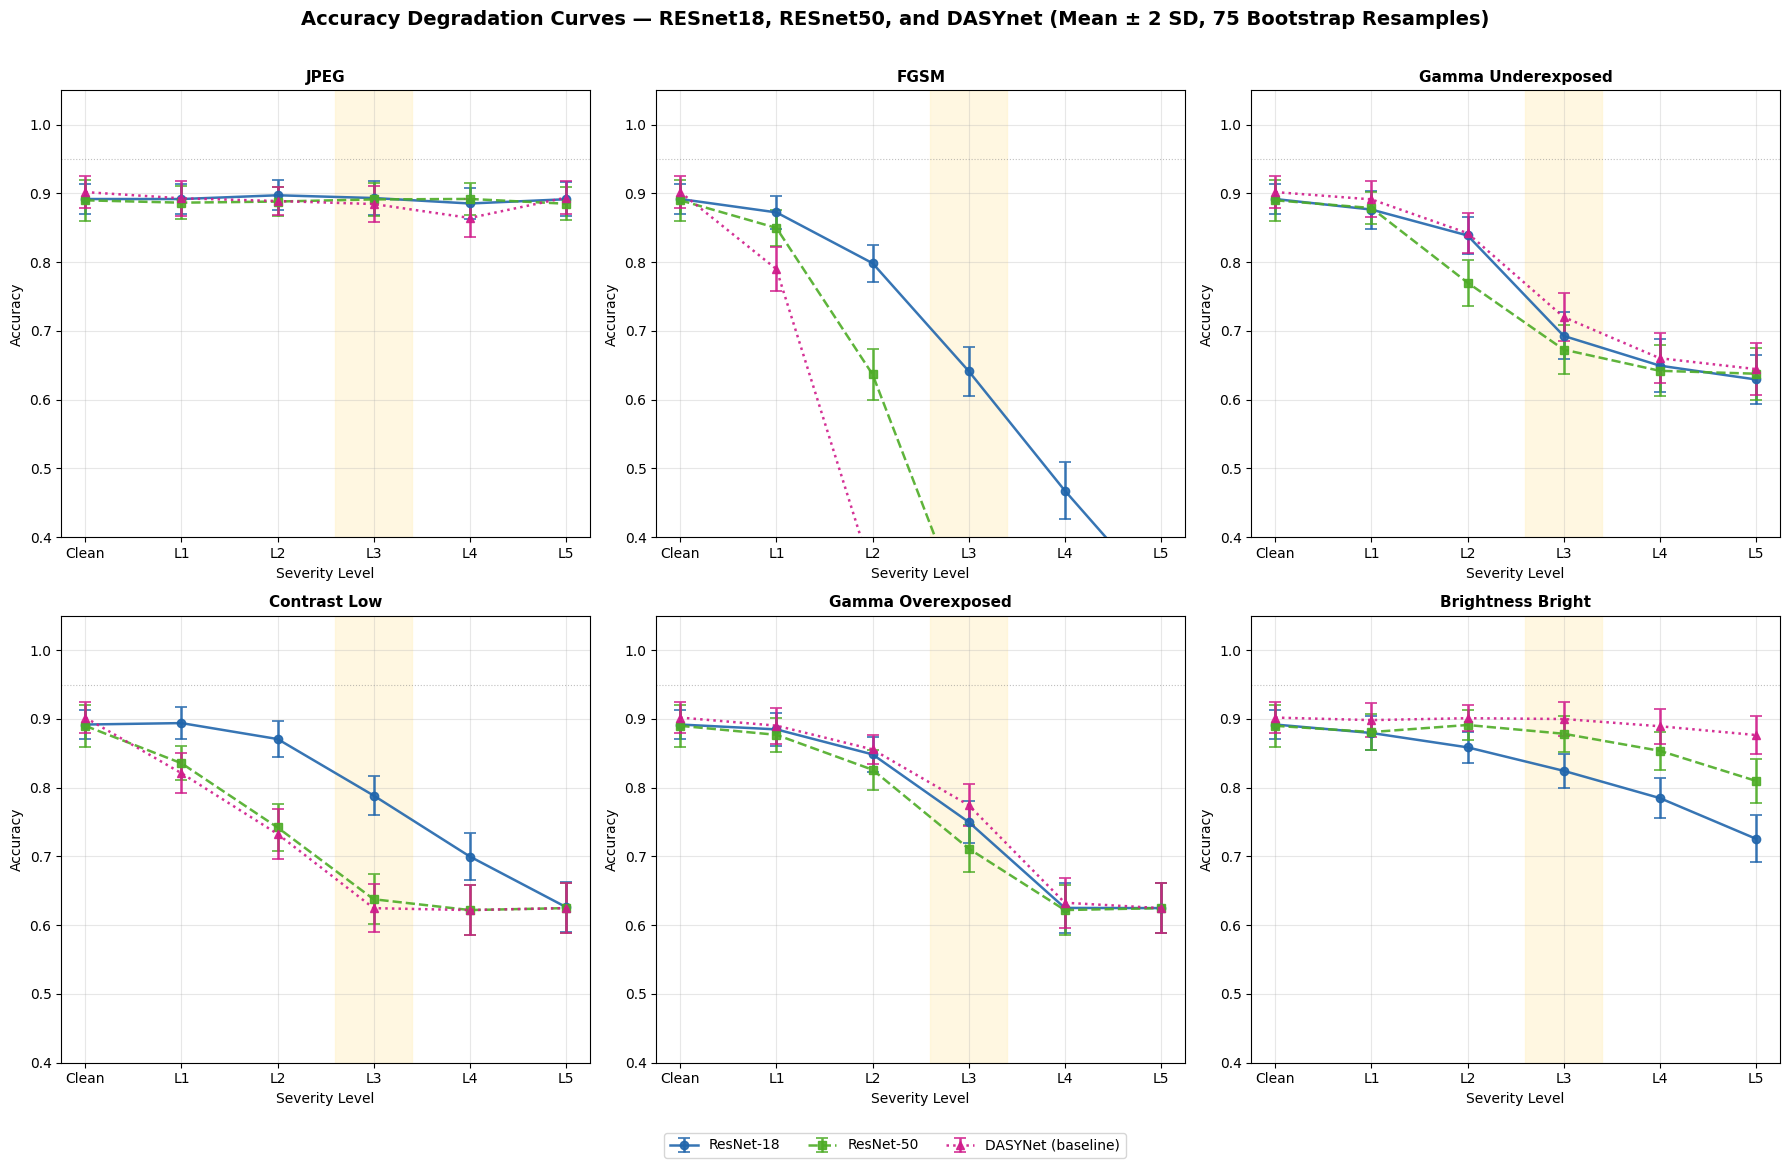

Degradation curves saved: figure_degradation_curves.png


In [35]:
MODEL_STYLES = {
    'ResNet-18'           : ('o-',  '#2166ac', 'ResNet-18'),
    'ResNet-50'           : ('s--', '#4dac26', 'ResNet-50'),
    'DASYNet (pneumonia)' : ('^:',  '#d01c8b', 'DASYNet (baseline)'),
}

x_pos    = list(range(6))  # 0 = Clean, 1–5 = L1–L5
x_labels = ['Clean', 'L1', 'L2', 'L3', 'L4', 'L5']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
fig.suptitle('Accuracy Degradation Curves — RESnet18, RESnet50, and DASYnet (Mean ± 2 SD, 75 Bootstrap Resamples)',
             fontsize=14, fontweight='bold', y=1.01)

for ax_idx, attack_name in enumerate(SELECTED_ATTACKS):
    ax = axes[ax_idx]

    for model_name, (fmt, color, label) in MODEL_STYLES.items():
        means = [baselines[model_name]['accuracy']['mean']]
        sd2s  = [baselines[model_name]['accuracy']['sd2']]

        for level_num in range(1, 6):
            bs  = all_results[model_name][attack_name][level_num]
            m   = np.mean(bs['accuracy'])
            s2  = 2 * np.std(bs['accuracy'])
            means.append(m)
            sd2s.append(s2)

        means = np.array(means)
        sd2s  = np.array(sd2s)

        ax.errorbar(x_pos, means, yerr=sd2s,
                    fmt=fmt, color=color, label=label,
                    capsize=4, capthick=1.2, linewidth=1.8,
                    markersize=6, alpha=0.9)

    # Shade Level-3 column
    ax.axvspan(2.6, 3.4, color='#fff3cd', alpha=0.6, zorder=0)
    ax.axhline(y=0.95, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

    ax.set_title(attack_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('Severity Level')
    ax.grid(True, alpha=0.3)

# Shared legend below all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.04), fontsize=10,
           frameon=True, fancybox=True)

plt.tight_layout()
plt.savefig('figure_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Degradation curves saved: figure_degradation_curves.png')

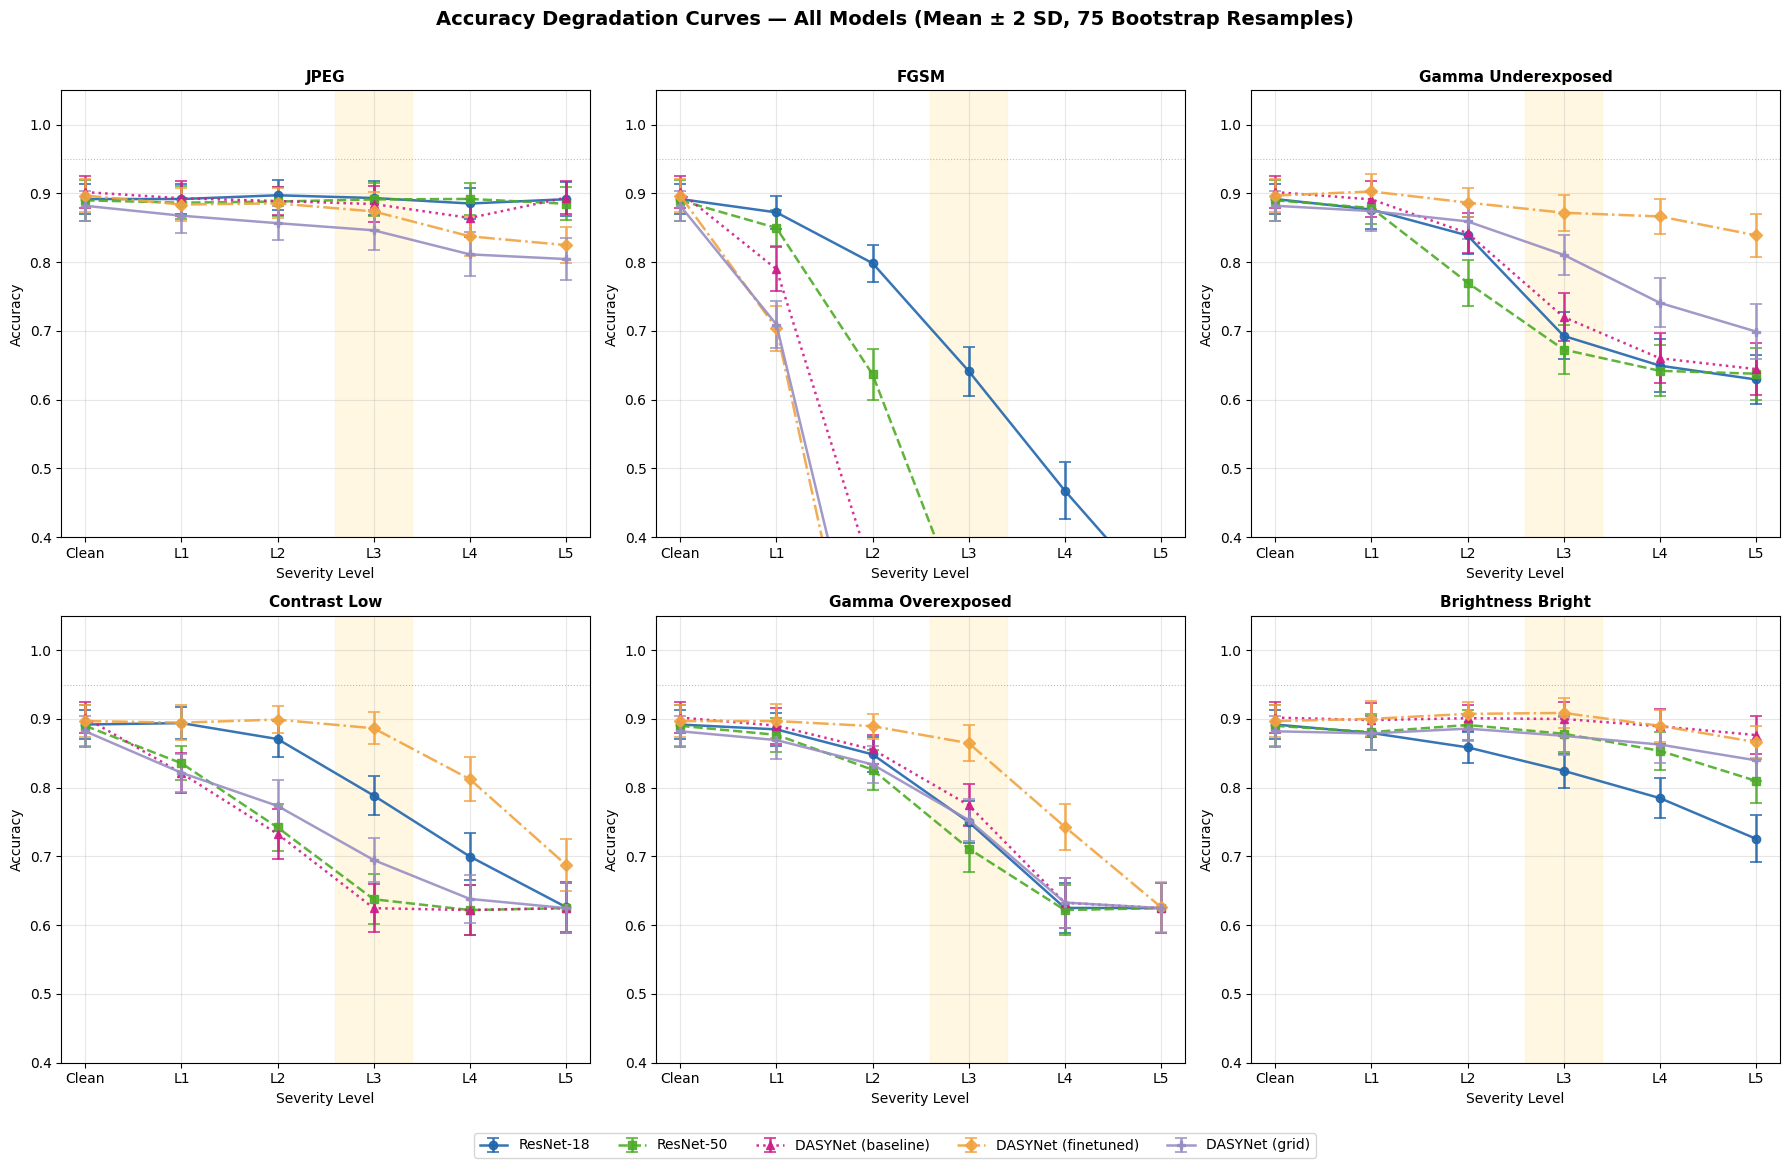

Degradation curves saved: figure_degradation_curves.png


In [17]:
MODEL_STYLES = {
    'ResNet-18'           : ('o-',  '#2166ac', 'ResNet-18'),
    'ResNet-50'           : ('s--', '#4dac26', 'ResNet-50'),
    'DASYNet (pneumonia)' : ('^:',  '#d01c8b', 'DASYNet (baseline)'),
    'DASYNet (finetuned)' : ('D-.', '#f1a340', 'DASYNet (finetuned)'),
    'DASYNet (grid)'      : ('P-',  '#998ec3', 'DASYNet (grid)'),
}

x_pos    = list(range(6))  # 0 = Clean, 1–5 = L1–L5
x_labels = ['Clean', 'L1', 'L2', 'L3', 'L4', 'L5']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
fig.suptitle('Accuracy Degradation Curves — All Models (Mean ± 2 SD, 75 Bootstrap Resamples)',
             fontsize=14, fontweight='bold', y=1.01)

for ax_idx, attack_name in enumerate(SELECTED_ATTACKS):
    ax = axes[ax_idx]

    for model_name, (fmt, color, label) in MODEL_STYLES.items():
        means = [baselines[model_name]['accuracy']['mean']]
        sd2s  = [baselines[model_name]['accuracy']['sd2']]

        for level_num in range(1, 6):
            bs  = all_results[model_name][attack_name][level_num]
            m   = np.mean(bs['accuracy'])
            s2  = 2 * np.std(bs['accuracy'])
            means.append(m)
            sd2s.append(s2)

        means = np.array(means)
        sd2s  = np.array(sd2s)

        ax.errorbar(x_pos, means, yerr=sd2s,
                    fmt=fmt, color=color, label=label,
                    capsize=4, capthick=1.2, linewidth=1.8,
                    markersize=6, alpha=0.9)

    # Shade Level-3 column
    ax.axvspan(2.6, 3.4, color='#fff3cd', alpha=0.6, zorder=0)
    ax.axhline(y=0.95, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

    ax.set_title(attack_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('Severity Level')
    ax.grid(True, alpha=0.3)

# Shared legend below all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.04), fontsize=10,
           frameon=True, fancybox=True)

plt.tight_layout()
plt.savefig('figure_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Degradation curves saved: figure_degradation_curves.png')

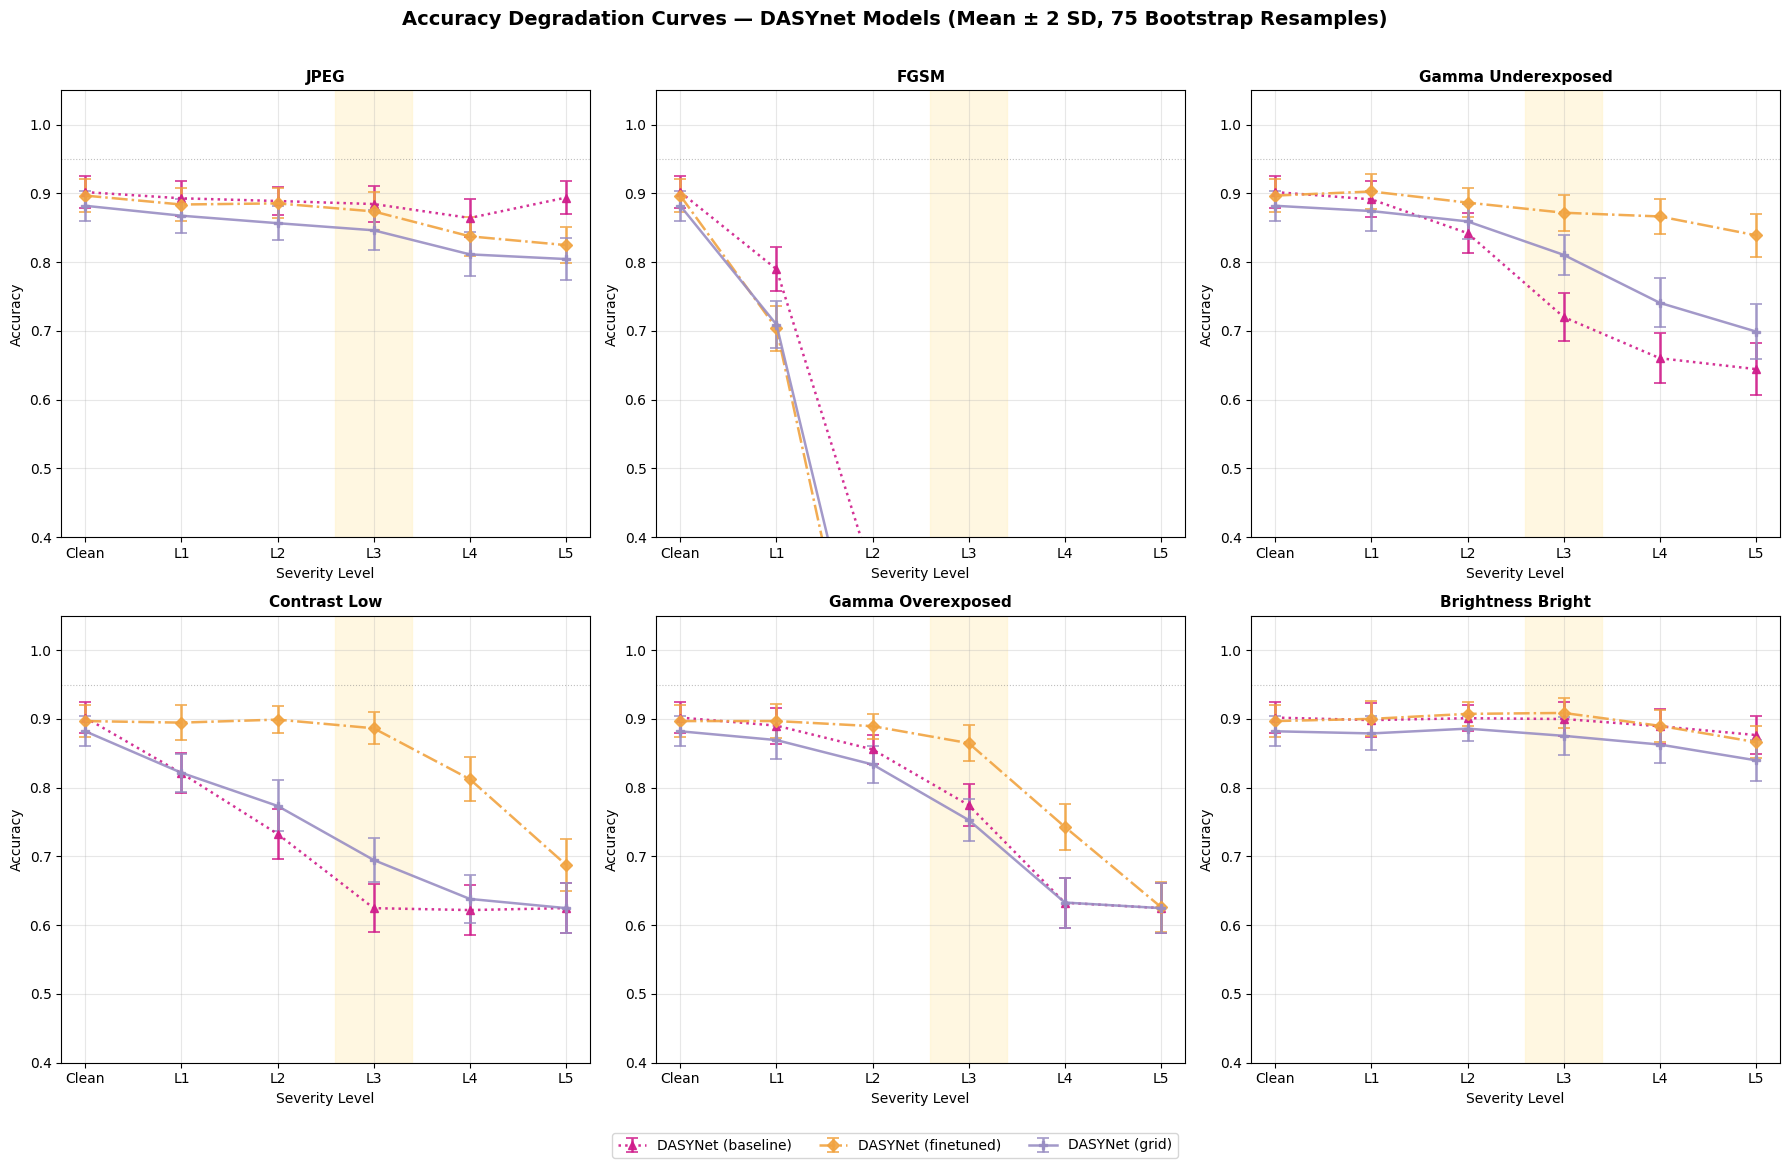

Degradation curves saved: figure_degradation_curves.png


In [36]:
MODEL_STYLES = {
    'DASYNet (pneumonia)' : ('^:',  '#d01c8b', 'DASYNet (baseline)'),
    'DASYNet (finetuned)' : ('D-.', '#f1a340', 'DASYNet (finetuned)'),
    'DASYNet (grid)'      : ('P-',  '#998ec3', 'DASYNet (grid)'),
}

x_pos    = list(range(6))  # 0 = Clean, 1–5 = L1–L5
x_labels = ['Clean', 'L1', 'L2', 'L3', 'L4', 'L5']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
fig.suptitle('Accuracy Degradation Curves — DASYnet Models (Mean ± 2 SD, 75 Bootstrap Resamples)',
             fontsize=14, fontweight='bold', y=1.01)

for ax_idx, attack_name in enumerate(SELECTED_ATTACKS):
    ax = axes[ax_idx]

    for model_name, (fmt, color, label) in MODEL_STYLES.items():
        means = [baselines[model_name]['accuracy']['mean']]
        sd2s  = [baselines[model_name]['accuracy']['sd2']]

        for level_num in range(1, 6):
            bs  = all_results[model_name][attack_name][level_num]
            m   = np.mean(bs['accuracy'])
            s2  = 2 * np.std(bs['accuracy'])
            means.append(m)
            sd2s.append(s2)

        means = np.array(means)
        sd2s  = np.array(sd2s)

        ax.errorbar(x_pos, means, yerr=sd2s,
                    fmt=fmt, color=color, label=label,
                    capsize=4, capthick=1.2, linewidth=1.8,
                    markersize=6, alpha=0.9)

    # Shade Level-3 column
    ax.axvspan(2.6, 3.4, color='#fff3cd', alpha=0.6, zorder=0)
    ax.axhline(y=0.95, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)

    ax.set_title(attack_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('Severity Level')
    ax.grid(True, alpha=0.3)

# Shared legend below all subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.04), fontsize=10,
           frameon=True, fancybox=True)

plt.tight_layout()
plt.savefig('figure_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Degradation curves saved: figure_degradation_curves.png')

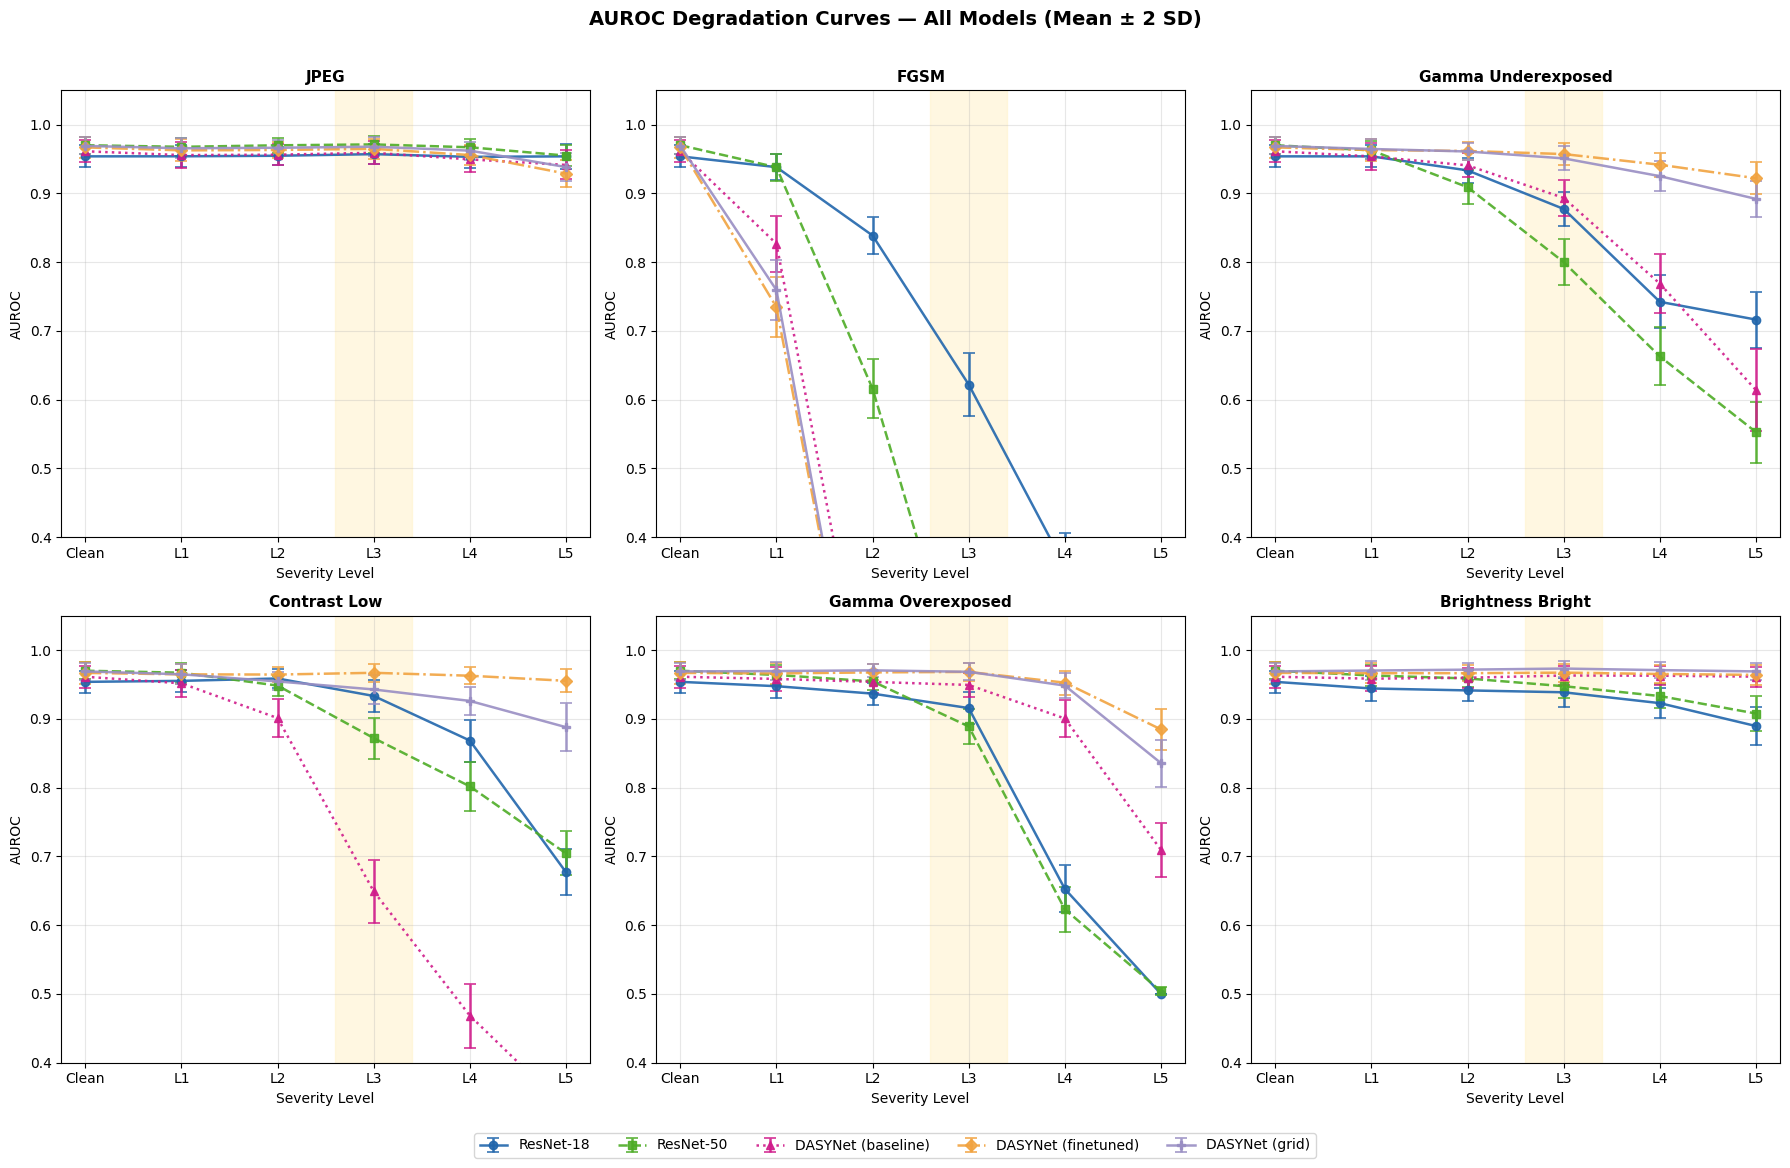

AUROC degradation curves saved.


In [18]:
# ── Per-metric degradation curves (AUROC) ─────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
fig.suptitle('AUROC Degradation Curves — All Models (Mean ± 2 SD)',
             fontsize=14, fontweight='bold', y=1.01)

for ax_idx, attack_name in enumerate(SELECTED_ATTACKS):
    ax = axes[ax_idx]

    for model_name, (fmt, color, label) in MODEL_STYLES.items():
        means = [baselines[model_name]['auroc']['mean']]
        sd2s  = [baselines[model_name]['auroc']['sd2']]

        for level_num in range(1, 6):
            bs  = all_results[model_name][attack_name][level_num]
            means.append(np.mean(bs['auroc']))
            sd2s.append(2 * np.std(bs['auroc']))

        ax.errorbar(x_pos, means, yerr=sd2s,
                    fmt=fmt, color=color, label=label,
                    capsize=4, capthick=1.2, linewidth=1.8,
                    markersize=6, alpha=0.9)

    ax.axvspan(2.6, 3.4, color='#fff3cd', alpha=0.6, zorder=0)
    ax.set_title(attack_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0.4, 1.05)
    ax.set_ylabel('AUROC')
    ax.set_xlabel('Severity Level')
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.04), fontsize=10,
           frameon=True, fancybox=True)

plt.tight_layout()
plt.savefig('figure_degradation_curves_auroc.png', dpi=150, bbox_inches='tight')
plt.show()
print('AUROC degradation curves saved.')

---
# PART 4 — Level-3 Metric Summary Table

Report-ready table: each metric shown as **mean ± 2 SD** for all 5 models × 6 attacks at Level 3.
Flagged if accuracy drop > 5% from clean baseline.

In [19]:
LEVEL_REPORT = 3  # Level 3 for the report metric table

rows = []
for model_name in ALL_MODELS:
    clean_acc = baselines[model_name]['accuracy']['mean']

    for attack_name in SELECTED_ATTACKS:
        bs  = all_results[model_name][attack_name][LEVEL_REPORT]
        sm  = summarize_bootstrap(bs)

        acc_drop = clean_acc - sm['accuracy']['mean']
        flag     = 'YES' if acc_drop > CONCERNING_THRESHOLD else ''

        def fmt(metric):
            m  = sm[metric]['mean']
            s2 = sm[metric]['sd2']
            return f'{m:.4f} ± {s2:.4f}'

        rows.append({
            'Model'         : model_name,
            'Attack'        : attack_name,
            'Accuracy'      : fmt('accuracy'),
            'AUROC'         : fmt('auroc'),
            'Precision'     : fmt('precision'),
            'Recall'        : fmt('recall'),
            'F1'            : fmt('f1'),
            'Acc Drop'      : f'{acc_drop:+.4f}',
            'Flagged (>5%)' : flag,
        })

df_l3 = pd.DataFrame(rows)

print(f'Level-3 Summary Table — {len(df_l3)} rows')
print(df_l3.to_string(index=False))

Level-3 Summary Table — 30 rows
              Model             Attack        Accuracy           AUROC       Precision          Recall              F1 Acc Drop Flagged (>5%)
          ResNet-18               JPEG 0.8933 ± 0.0243 0.9571 ± 0.0145 0.8695 ± 0.0284 0.9745 ± 0.0149 0.9190 ± 0.0185  -0.0015              
          ResNet-18               FGSM 0.6415 ± 0.0358 0.6220 ± 0.0454 0.6927 ± 0.0395 0.7600 ± 0.0432 0.7246 ± 0.0335  +0.2503           YES
          ResNet-18 Gamma Underexposed 0.6927 ± 0.0341 0.8774 ± 0.0251 0.6696 ± 0.0356 0.9976 ± 0.0053 0.8012 ± 0.0253  +0.1991           YES
          ResNet-18       Contrast Low 0.7885 ± 0.0286 0.9334 ± 0.0227 0.7460 ± 0.0335 1.0000 ± 0.0000 0.8544 ± 0.0220  +0.1033           YES
          ResNet-18  Gamma Overexposed 0.7500 ± 0.0304 0.9158 ± 0.0234 0.7147 ± 0.0336 0.9948 ± 0.0068 0.8317 ± 0.0230  +0.1418           YES
          ResNet-18  Brightness Bright 0.8245 ± 0.0244 0.9387 ± 0.0207 0.7846 ± 0.0291 0.9889 ± 0.0109 0.8749 ± 0.01

In [20]:
# ── Styled interactive display ────────────────────────────────────────────────
def highlight_flagged(row):
    if row['Flagged (>5%)'] == 'YES':
        return ['background-color: #fde8e8'] * len(row)
    return [''] * len(row)


styled = (
    df_l3.style
    .apply(highlight_flagged, axis=1)
    .set_properties(**{'font-size': '11px', 'text-align': 'center'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#4a4a4a'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center')]
    }])
    .set_caption('Level-3 Corruption Metrics (Mean ± 2 SD, 75 Bootstrap Resamples). Red = Flagged (Accuracy Drop > 5%)')
)

display(styled)

,Model,Attack,Accuracy,AUROC,Precision,Recall,F1,Acc Drop,Flagged (>5%)
0,ResNet-18,JPEG,0.8933 ± 0.0243,0.9571 ± 0.0145,0.8695 ± 0.0284,0.9745 ± 0.0149,0.9190 ± 0.0185,-0.0015,
1,ResNet-18,FGSM,0.6415 ± 0.0358,0.6220 ± 0.0454,0.6927 ± 0.0395,0.7600 ± 0.0432,0.7246 ± 0.0335,+0.2503,YES
2,ResNet-18,Gamma Underexposed,0.6927 ± 0.0341,0.8774 ± 0.0251,0.6696 ± 0.0356,0.9976 ± 0.0053,0.8012 ± 0.0253,+0.1991,YES
3,ResNet-18,Contrast Low,0.7885 ± 0.0286,0.9334 ± 0.0227,0.7460 ± 0.0335,1.0000 ± 0.0000,0.8544 ± 0.0220,+0.1033,YES
4,ResNet-18,Gamma Overexposed,0.7500 ± 0.0304,0.9158 ± 0.0234,0.7147 ± 0.0336,0.9948 ± 0.0068,0.8317 ± 0.0230,+0.1418,YES
5,ResNet-18,Brightness Bright,0.8245 ± 0.0244,0.9387 ± 0.0207,0.7846 ± 0.0291,0.9889 ± 0.0109,0.8749 ± 0.0191,+0.0673,YES
6,ResNet-50,JPEG,0.8913 ± 0.0242,0.9713 ± 0.0120,0.8656 ± 0.0292,0.9766 ± 0.0160,0.9177 ± 0.0194,-0.0013,
7,ResNet-50,FGSM,0.2729 ± 0.0349,0.1462 ± 0.0351,0.3957 ± 0.0501,0.3234 ± 0.0439,0.3556 ± 0.0426,+0.6170,YES
8,ResNet-50,Gamma Underexposed,0.6728 ± 0.0354,0.8001 ± 0.0335,0.6561 ± 0.0362,0.9948 ± 0.0075,0.7906 ± 0.0259,+0.2171,YES
9,ResNet-50,Contrast Low,0.6377 ± 0.0363,0.8721 ± 0.0298,0.6316 ± 0.0356,1.0000 ± 0.0000,0.7741 ± 0.0268,+0.2523,YES


In [ ]:
# ── Save to CSV ───────────────────────────────────────────────────────────────
df_l3.to_csv('level3_metric_summary.csv', index=False)
print('Saved: level3_metric_summary.csv')

---
# PART 5 — Bootstrap Mean Distribution Plots

For each model, show the distribution of bootstrap accuracy means across all attacks at Level 3.
This visualizes how stable each model's estimates are and where its performance concentrates.

In [41]:
# Re-run FGSM bootstrap for all models with the fixed run_fgsm_inference
print('Re-running FGSM bootstrap with fixed inference function...')

for model_name, (model, grayscale) in ALL_MODELS.items():
    print(f'  {model_name}')
    all_results[model_name]['FGSM'] = {}

    for level_idx in range(5):
        level_num = level_idx + 1
        bs_vals = bootstrap_attack(
            model, 'FGSM', level_idx, grayscale,
            n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED + level_idx
        )
        all_results[model_name]['FGSM'][level_num] = bs_vals
        summary = summarize_bootstrap(bs_vals)
        acc_m   = summary['accuracy']['mean']
        acc_sd2 = summary['accuracy']['sd2']
        print(f'    L{level_num}: Acc = {acc_m:.4f} ± {acc_sd2:.4f}')

print('Done. Re-run the distribution plot cell now.')

Re-running FGSM bootstrap with fixed inference function...
  ResNet-18
    L1: Acc = 0.8776 ± 0.0243
    L2: Acc = 0.8222 ± 0.0282
    L3: Acc = 0.7544 ± 0.0358
    L4: Acc = 0.6434 ± 0.0357
    L5: Acc = 0.5391 ± 0.0387
  ResNet-50
    L1: Acc = 0.8501 ± 0.0259
    L2: Acc = 0.7579 ± 0.0309
    L3: Acc = 0.5208 ± 0.0358
    L4: Acc = 0.3283 ± 0.0360
    L5: Acc = 0.2487 ± 0.0384
  DASYNet (pneumonia)
    L1: Acc = 0.7864 ± 0.0327
    L2: Acc = 0.4610 ± 0.0435
    L3: Acc = 0.2493 ± 0.0370
    L4: Acc = 0.1879 ± 0.0308
    L5: Acc = 0.1896 ± 0.0311
  DASYNet (finetuned)
    L1: Acc = 0.7410 ± 0.0299
    L2: Acc = 0.6510 ± 0.0397
    L3: Acc = 0.6176 ± 0.0361
    L4: Acc = 0.6043 ± 0.0366
    L5: Acc = 0.6140 ± 0.0340
  DASYNet (grid)
    L1: Acc = 0.7556 ± 0.0341
    L2: Acc = 0.7113 ± 0.0362
    L3: Acc = 0.6597 ± 0.0312
    L4: Acc = 0.6354 ± 0.0360
    L5: Acc = 0.6578 ± 0.0365
Done. Re-run the distribution plot cell now.


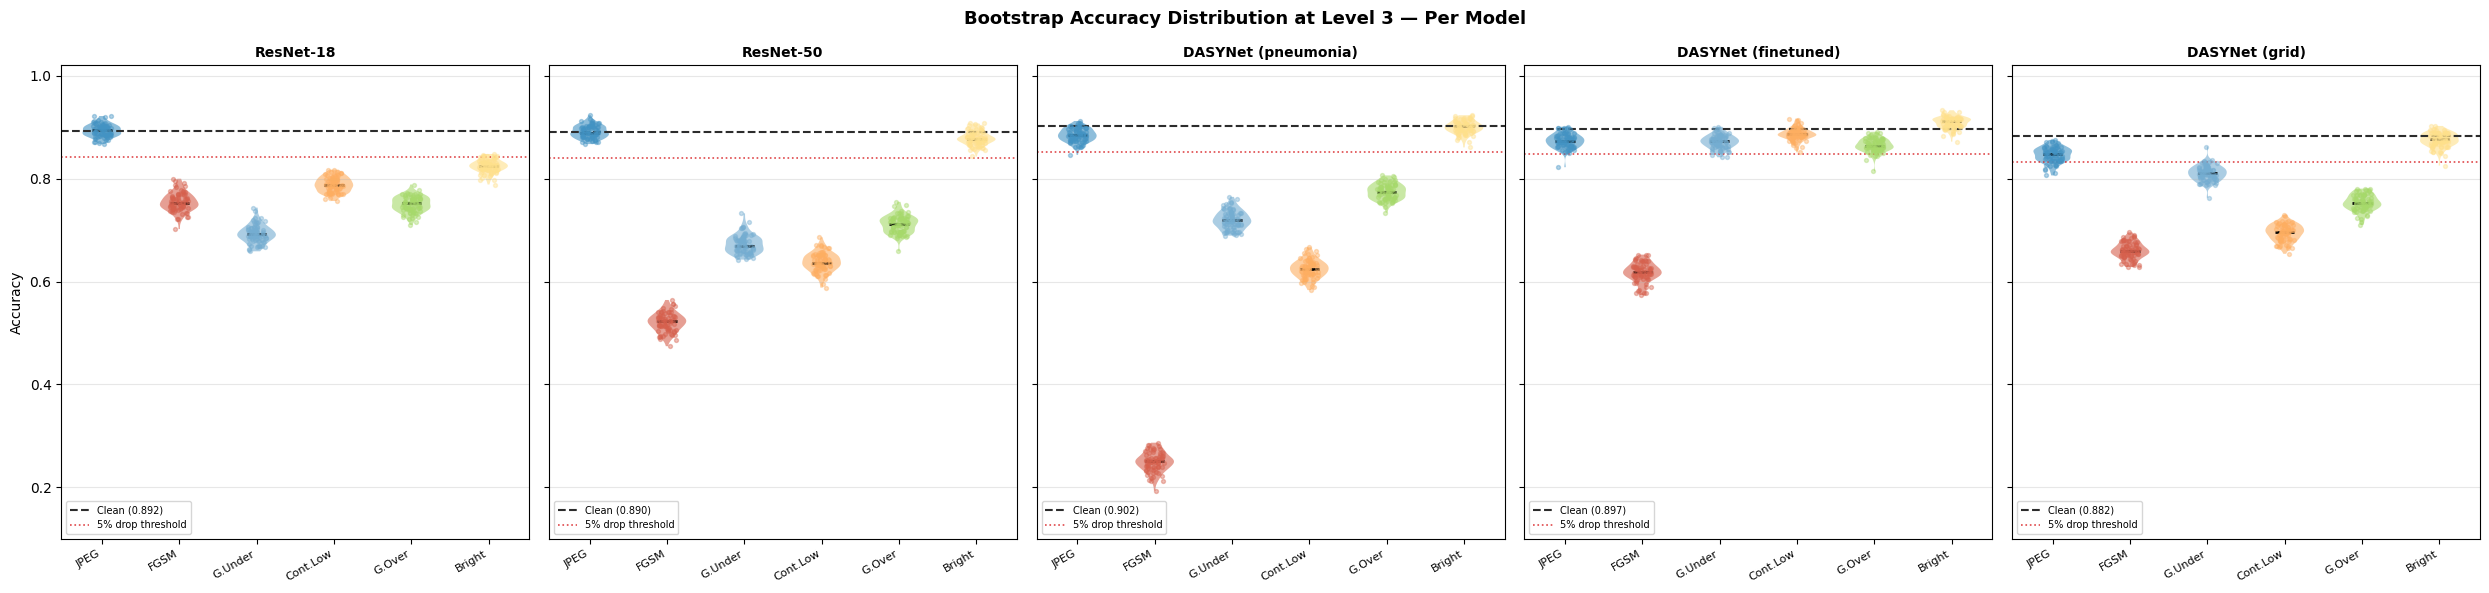

Bootstrap distribution plot saved: figure_bootstrap_distributions_per_model.png


In [47]:
# ── Distribution of bootstrap accuracy means per model ────────────────────────
# One subplot per model, violin + strip plot for each attack

n_models = len(ALL_MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 6), sharey=True)
fig.suptitle('Bootstrap Accuracy Distribution at Level 3 — Per Model',
             fontsize=13, fontweight='bold')

attack_short = {
    'JPEG'              : 'JPEG',
    'FGSM'              : 'FGSM',
    'Gamma Underexposed': 'G.Under',
    'Contrast Low'      : 'Cont.Low',
    'Gamma Overexposed' : 'G.Over',
    'Brightness Bright' : 'Bright',
}

ATTACK_COLORS = [
    '#4393c3', '#d6604d', '#74add1', '#fdae61', '#a6d96a', '#fee08b'
]

for ax_idx, (model_name, _) in enumerate(ALL_MODELS.items()):
    ax          = axes[ax_idx]
    clean_acc   = baselines[model_name]['accuracy']['mean']

    plot_data   = []
    plot_labels = []
    plot_colors = []

    for atk_i, attack_name in enumerate(SELECTED_ATTACKS):
        bs_acc = all_results[model_name][attack_name][LEVEL_REPORT]['accuracy']
        plot_data.append(bs_acc)
        plot_labels.append(attack_short[attack_name])
        plot_colors.append(ATTACK_COLORS[atk_i])

    parts = ax.violinplot(plot_data, positions=range(len(SELECTED_ATTACKS)),
                          showmedians=True, showextrema=False)

    for pc, color in zip(parts['bodies'], plot_colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    # Scatter jitter overlay
    for j, (data, color) in enumerate(zip(plot_data, plot_colors)):
        jitter = np.random.RandomState(j).uniform(-0.12, 0.12, size=len(data))
        ax.scatter(j + jitter, data, alpha=0.4, s=8, color=color, zorder=3)

    # Clean baseline reference line
    ax.axhline(y=clean_acc, color='#2c2c2c', linestyle='--',
               linewidth=1.5, label=f'Clean ({clean_acc:.3f})')

    # Flag threshold line
    ax.axhline(y=clean_acc - CONCERNING_THRESHOLD, color='#d7191c',
               linestyle=':', linewidth=1.2, alpha=0.8, label='5% drop threshold')

    ax.set_title(model_name, fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(SELECTED_ATTACKS)))
    ax.set_xticklabels(plot_labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy' if ax_idx == 0 else '')
    ax.set_ylim(0.1, 1.02)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.savefig('figure_bootstrap_distributions_per_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bootstrap distribution plot saved: figure_bootstrap_distributions_per_model.png')

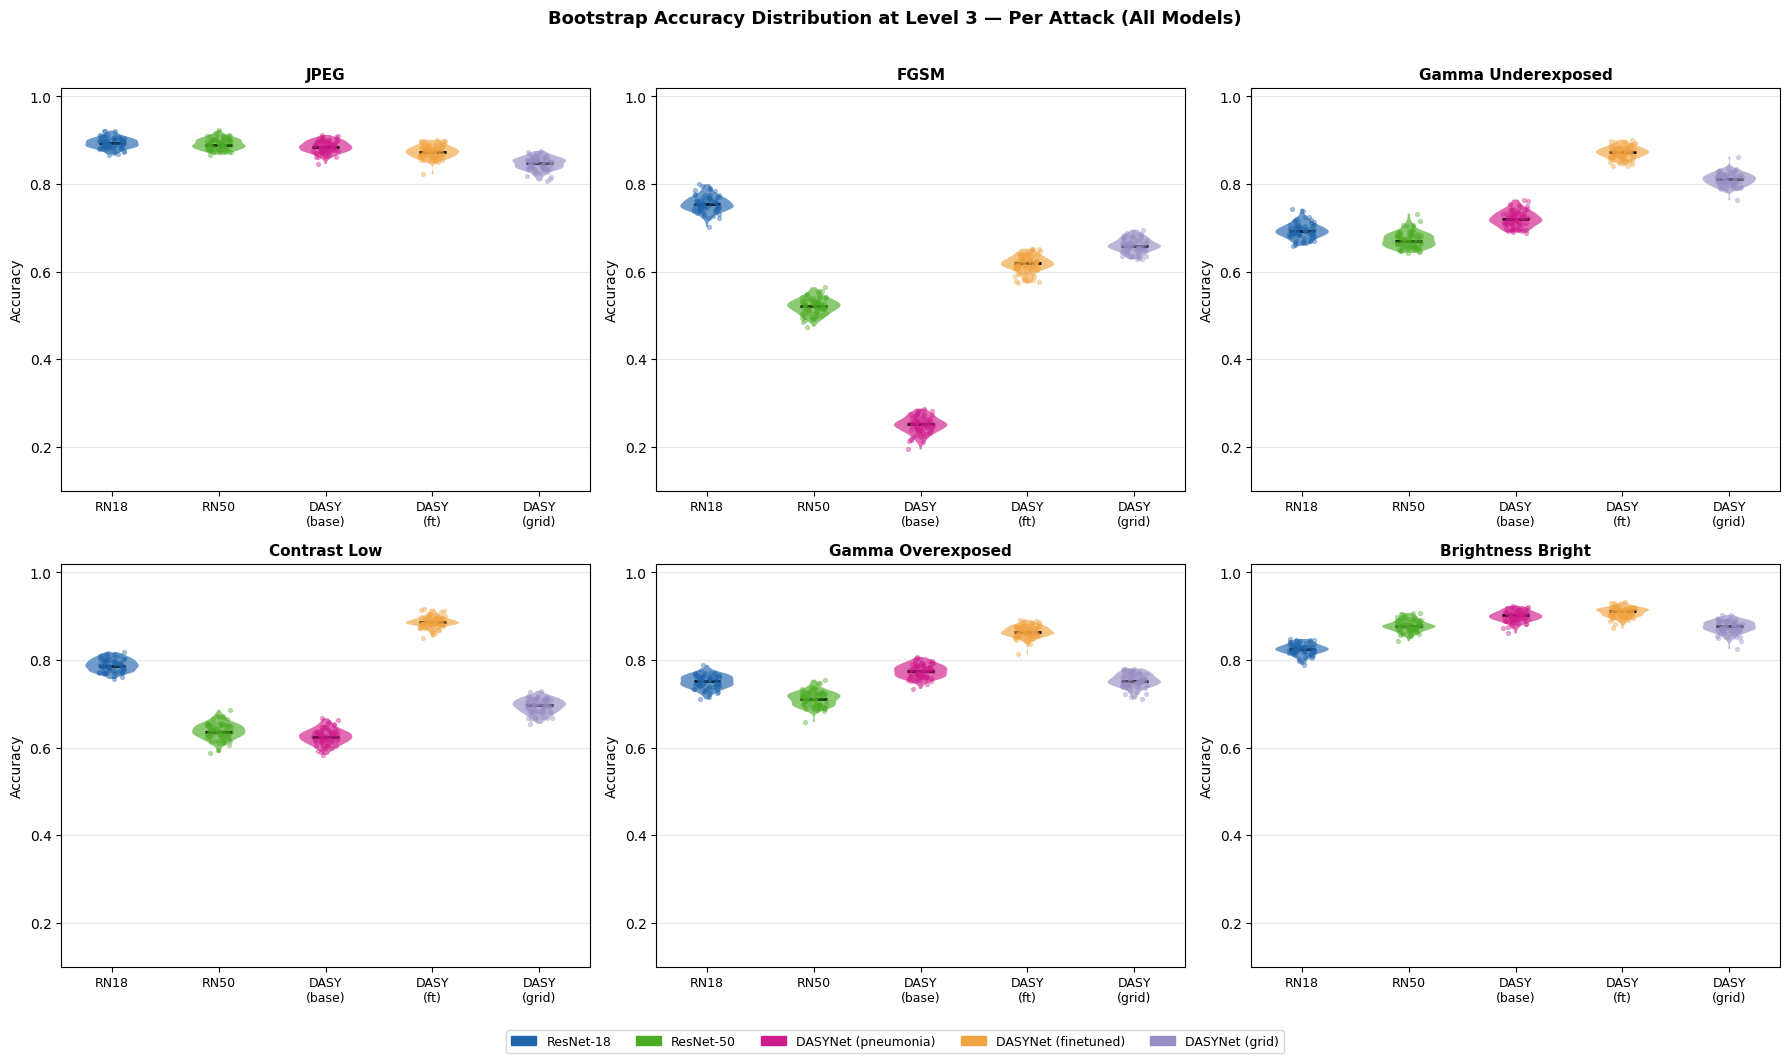

Per-attack distribution plot saved: figure_bootstrap_distributions_per_attack.png


In [48]:
# ── Distribution grouped by attack (across models) ─────────────────────────
# Complementary view: for each attack, compare all models side by side

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle('Bootstrap Accuracy Distribution at Level 3 — Per Attack (All Models)',
             fontsize=13, fontweight='bold', y=1.01)

MODEL_COLORS = {
    'ResNet-18'           : '#2166ac',
    'ResNet-50'           : '#4dac26',
    'DASYNet (pneumonia)' : '#d01c8b',
    'DASYNet (finetuned)' : '#f1a340',
    'DASYNet (grid)'      : '#998ec3',
}

model_names_list = list(ALL_MODELS.keys())

for ax_idx, attack_name in enumerate(SELECTED_ATTACKS):
    ax = axes[ax_idx]

    plot_data   = []
    plot_colors = []

    for mn in model_names_list:
        bs_acc = all_results[mn][attack_name][LEVEL_REPORT]['accuracy']
        plot_data.append(bs_acc)
        plot_colors.append(MODEL_COLORS[mn])

    parts = ax.violinplot(plot_data, positions=range(len(model_names_list)),
                          showmedians=True, showextrema=False)

    for pc, color in zip(parts['bodies'], plot_colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    for j, (data, color) in enumerate(zip(plot_data, plot_colors)):
        jitter = np.random.RandomState(j + 100).uniform(-0.12, 0.12, size=len(data))
        ax.scatter(j + jitter, data, alpha=0.35, s=8, color=color, zorder=3)

    ax.set_title(attack_name, fontsize=11, fontweight='bold')
    short_labels = ['RN18', 'RN50', 'DASY\n(base)', 'DASY\n(ft)', 'DASY\n(grid)']
    ax.set_xticks(range(len(model_names_list)))
    ax.set_xticklabels(short_labels, fontsize=9)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.1, 1.02)
    ax.grid(True, axis='y', alpha=0.3)

# Legend patches
legend_patches = [mpatches.Patch(color=MODEL_COLORS[mn], label=mn) for mn in model_names_list]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.04), fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('figure_bootstrap_distributions_per_attack.png', dpi=150, bbox_inches='tight')
plt.show()
print('Per-attack distribution plot saved: figure_bootstrap_distributions_per_attack.png')

---
# PART 6 — Model Comparison Heatmap

Compact heatmap of mean accuracy at Level 3 for all models × attacks.
Red = low accuracy (high vulnerability), blue = high accuracy (robust).

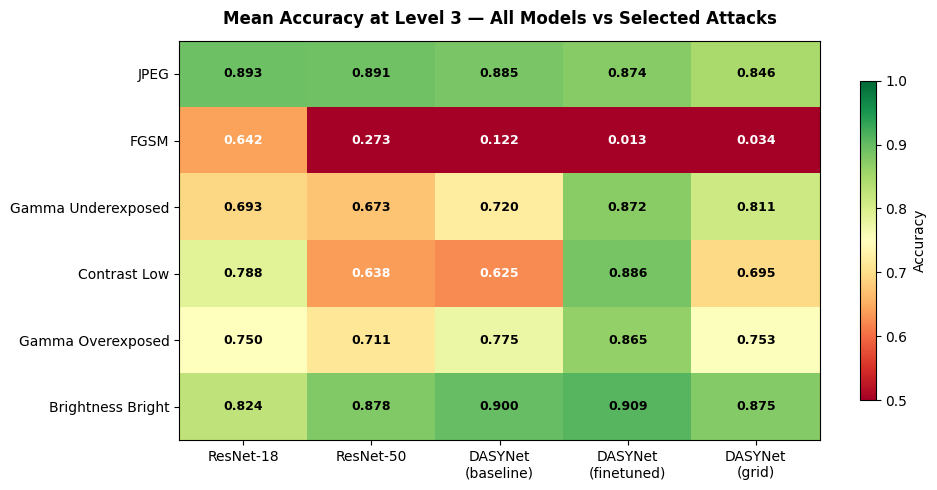

Heatmap saved: figure_accuracy_heatmap_l3.png


In [23]:
# Build accuracy matrix for heatmap
model_names_list = list(ALL_MODELS.keys())
short_model_labels = ['ResNet-18', 'ResNet-50', 'DASYNet\n(baseline)', 'DASYNet\n(finetuned)', 'DASYNet\n(grid)']

acc_matrix = np.zeros((len(SELECTED_ATTACKS), len(model_names_list)))

for j, model_name in enumerate(model_names_list):
    for i, attack_name in enumerate(SELECTED_ATTACKS):
        bs  = all_results[model_name][attack_name][LEVEL_REPORT]
        acc_matrix[i, j] = np.mean(bs['accuracy'])

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(acc_matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Accuracy')

ax.set_xticks(range(len(model_names_list)))
ax.set_xticklabels(short_model_labels, fontsize=10)
ax.set_yticks(range(len(SELECTED_ATTACKS)))
ax.set_yticklabels(SELECTED_ATTACKS, fontsize=10)
ax.set_title('Mean Accuracy at Level 3 — All Models vs Selected Attacks',
             fontsize=12, fontweight='bold', pad=12)

# Annotate cells
for i in range(len(SELECTED_ATTACKS)):
    for j in range(len(model_names_list)):
        val = acc_matrix[i, j]
        text_color = 'white' if val < 0.65 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, color=text_color, fontweight='bold')

plt.tight_layout()
plt.savefig('figure_accuracy_heatmap_l3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved: figure_accuracy_heatmap_l3.png')

---
# PART 7 — Full Numeric Summary

Print all metrics for every model, attack, and level for record-keeping.

In [24]:
print('=' * 80)
print('FULL BOOTSTRAP SUMMARY — ALL MODELS, ALL ATTACKS, ALL LEVELS')
print('Format: mean ± 2SD  |  N_BOOTSTRAP =', N_BOOTSTRAP)
print('=' * 80)

for model_name in ALL_MODELS:
    clean = baselines[model_name]
    print(f'\n{model_name}')
    print(f'  Clean Acc  : {clean["accuracy"]["mean"]:.4f} ± {clean["accuracy"]["sd2"]:.4f}')
    print(f'  Clean AUROC: {clean["auroc"]["mean"]:.4f} ± {clean["auroc"]["sd2"]:.4f}')

    for attack_name in SELECTED_ATTACKS:
        print(f'\n  [{attack_name}]')
        for level_num in range(1, 6):
            bs  = all_results[model_name][attack_name][level_num]
            sm  = summarize_bootstrap(bs)
            acc_drop = clean['accuracy']['mean'] - sm['accuracy']['mean']
            flag = ' <-- FLAGGED' if acc_drop > CONCERNING_THRESHOLD else ''
            print(f'    L{level_num}: Acc={sm["accuracy"]["mean"]:.4f}±{sm["accuracy"]["sd2"]:.4f}  '
                  f'AUROC={sm["auroc"]["mean"]:.4f}±{sm["auroc"]["sd2"]:.4f}  '
                  f'Recall={sm["recall"]["mean"]:.4f}±{sm["recall"]["sd2"]:.4f}  '
                  f'Drop={acc_drop:+.4f}{flag}')

print('\n' + '=' * 80)

FULL BOOTSTRAP SUMMARY — ALL MODELS, ALL ATTACKS, ALL LEVELS
Format: mean ± 2SD  |  N_BOOTSTRAP = 75

ResNet-18
  Clean Acc  : 0.8918 ± 0.0213
  Clean AUROC: 0.9539 ± 0.0159

  [JPEG]
    L1: Acc=0.8918±0.0213  AUROC=0.9540±0.0159  Recall=0.9751±0.0160  Drop=+0.0000
    L2: Acc=0.8973±0.0216  AUROC=0.9548±0.0131  Recall=0.9758±0.0164  Drop=-0.0055
    L3: Acc=0.8933±0.0243  AUROC=0.9571±0.0145  Recall=0.9745±0.0149  Drop=-0.0015
    L4: Acc=0.8853±0.0229  AUROC=0.9532±0.0159  Recall=0.9738±0.0155  Drop=+0.0065
    L5: Acc=0.8915±0.0248  AUROC=0.9539±0.0180  Recall=0.9878±0.0127  Drop=+0.0003

  [FGSM]
    L1: Acc=0.8724±0.0243  AUROC=0.9382±0.0188  Recall=0.9724±0.0165  Drop=+0.0194
    L2: Acc=0.7985±0.0271  AUROC=0.8388±0.0270  Recall=0.9141±0.0274  Drop=+0.0933 <-- FLAGGED
    L3: Acc=0.6415±0.0358  AUROC=0.6220±0.0454  Recall=0.7600±0.0432  Drop=+0.2503 <-- FLAGGED
    L4: Acc=0.4676±0.0414  AUROC=0.3580±0.0487  Recall=0.5510±0.0513  Drop=+0.4242 <-- FLAGGED
    L5: Acc=0.3086±0.03

In [ ]:
# Save full results to CSV for easy importing into the report
all_rows = []

for model_name in ALL_MODELS:
    clean_acc = baselines[model_name]['accuracy']['mean']

    # Add clean baseline row
    for metric in ['accuracy', 'auroc', 'precision', 'recall', 'f1']:
        all_rows.append({
            'model'  : model_name,
            'attack' : 'Clean',
            'level'  : 0,
            'metric' : metric,
            'mean'   : baselines[model_name][metric]['mean'],
            'sd2'    : baselines[model_name][metric]['sd2'],
        })

    for attack_name in SELECTED_ATTACKS:
        for level_num in range(1, 6):
            bs = all_results[model_name][attack_name][level_num]
            sm = summarize_bootstrap(bs)
            for metric in ['accuracy', 'auroc', 'precision', 'recall', 'f1']:
                all_rows.append({
                    'model'    : model_name,
                    'attack'   : attack_name,
                    'level'    : level_num,
                    'metric'   : metric,
                    'mean'     : sm[metric]['mean'],
                    'sd2'      : sm[metric]['sd2'],
                    'acc_drop' : clean_acc - sm['accuracy']['mean'] if metric == 'accuracy' else None,
                })

df_all = pd.DataFrame(all_rows)
df_all.to_csv('full_bootstrap_results.csv', index=False)
print(f'Full results saved: full_bootstrap_results.csv ({len(df_all)} rows)')

---
## Output File Summary

| File | Description |
|------|-------------|
| `figure_A_attacks_level3.png` | 2×3 grid of 6 attacks at Level 3 (report Figure A) |
| `figure_B_gamma_underexposed_levels.png` | Gamma Underexposed L0–L5 (report Figure B) |
| `figure_B2_fgsm_levels.png` | FGSM L0–L5 (report Figure B2) |
| `figure_degradation_curves.png` | Accuracy degradation curves all models with ±2SD error bars |
| `figure_degradation_curves_auroc.png` | Same for AUROC |
| `figure_bootstrap_distributions_per_model.png` | Bootstrap accuracy distributions per model |
| `figure_bootstrap_distributions_per_attack.png` | Bootstrap accuracy distributions per attack |
| `figure_accuracy_heatmap_l3.png` | Heatmap of L3 accuracy across all models and attacks |
| `level3_metric_summary.csv` | Level-3 summary table (mean ± 2SD per metric) |
| `full_bootstrap_results.csv` | Complete results for all models/attacks/levels/metrics |